# MODELO DE CLASIFICACIÓN ENFERMEDADES RELACIONADAS CON EL SUEÑO - ESTIMACIÓN DEL RIESGO DE APNEA

Al observar que la extracción de datos únicamente de fuente propia mediante el O2Ring resultaba muy costoso, se ha optado por tomar un dataset ya existente que cumple con las características que se requiere. (Dataset de kaggle)

Se tratará de generar un modelo de clasificación para la estimación del riesgo de padecer apnea del sueño u otras enfermedades relacionadas con el sueño.

In [1]:
!pip install graphviz

In [2]:
from graphviz import Digraph

dot = Digraph()

dot.node('A', 'Recogida de datos')
dot.node('B', 'Preprocesamiento')
dot.node('C', 'Análisis exploratorio')
dot.node('D', 'Entrenamiento del modelo')
dot.node('E', 'Evaluación')
dot.node('F', 'Integración en la App')

dot.edges(['AB', 'BC', 'CD', 'DE', 'EF'])

dot.render('diagrama_flujo', format='png', cleanup=True)

'diagrama_flujo.png'

In [3]:
from graphviz import Digraph

dot = Digraph()
dot.attr(rankdir='LR')  # Dirección horizontal
dot.attr('node', shape='box', style='rounded,filled', fillcolor='lightblue')

# Definición de los nodos
dot.node('A', 'Recogida de datos')
dot.node('B', 'Preprocesamiento')
dot.node('C', 'Análisis exploratorio')
dot.node('D', 'Entrenamiento del modelo')
dot.node('E', 'Evaluación')
dot.node('F', 'Integración en la App')

# Conexiones
dot.edges(['AB', 'BC', 'CD', 'DE', 'EF'])

# Generar el archivo
dot.render('diagrama_flujo_horizontal_redondeado', format='png', cleanup=True)


'diagrama_flujo_horizontal_redondeado.png'

## 1. IMPORTACIÓN DE LOS DATOS Y PRIMERAS VISUALIZACIONES

CARGAR LIBRERÍAS NECESARIAS

In [4]:
# Carga de las librerías necesarias
import pandas as pd
import numpy as np

# Para visualizar mejor los datos
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE


# Configuración de gráficos
sns.set(style="whitegrid")

C:\Users\Marina\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


CARGAR EL DATASET

In [5]:
ruta = r"C:\Users\Marina\OneDrive - Universidad de Burgos\Escritorio\TFG-Marina-Martin\datos\Sleep_health_and_lifestyle_dataset.csv"

# Cargar el dataset
df = pd.read_csv(ruta)

# Mostrar las primeras filas
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


REVISAR INFORMACIÓN GENERAL

In [6]:
# Ver información general sobre las columnas y tipos de datos
df.info()

# Ver valores nulos en el dataset
print("\nValores nulos en cada columna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB

Valores nulos en cada

In [7]:
df.duplicated().sum()

0

INFORMACIÓN GENERAL DEL DATASET

In [8]:
# Ver información general sobre las columnas y tipos de datos
df.info()

# Ver valores nulos en el dataset
print("\nValores nulos en cada columna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB

Valores nulos en cada

DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS

In [9]:
# Resumen estadístico de las columnas numéricas
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


REVISAR VALORES ÚNICOS EN LAS VARIABLES CATEGÓRICAS

In [10]:
# Ver los valores únicos de cada variable categórica
categorical_columns = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
for col in categorical_columns:
    print(f"\n{col} - Valores únicos:")
    print(df[col].unique())



Gender - Valores únicos:
['Male' 'Female']

Occupation - Valores únicos:
['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']

BMI Category - Valores únicos:
['Overweight' 'Normal' 'Obese' 'Normal Weight']

Sleep Disorder - Valores únicos:
['None' 'Sleep Apnea' 'Insomnia']


## 2. ANÁLISIS ESTADISTICO

A) VARIABLES NUMÉRICAS

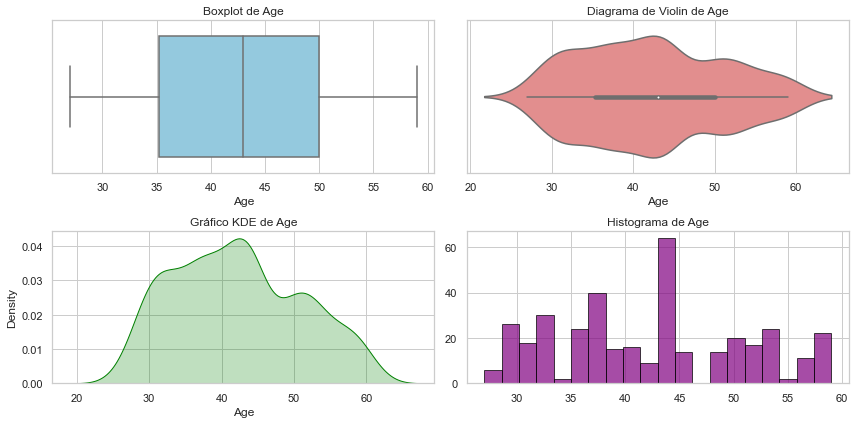

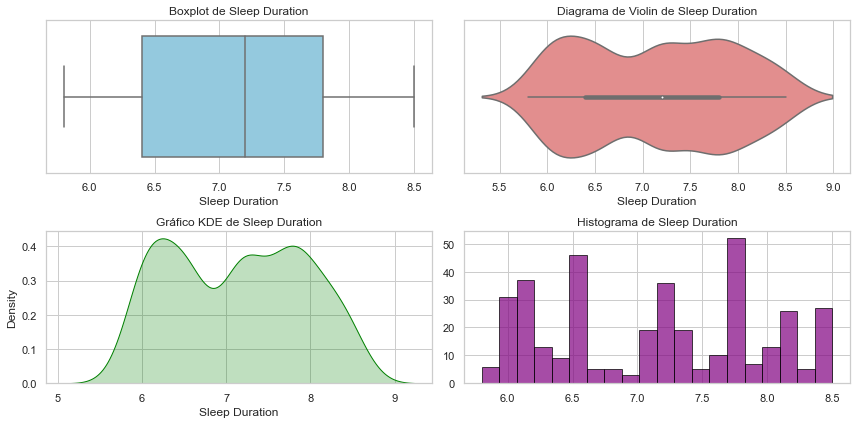

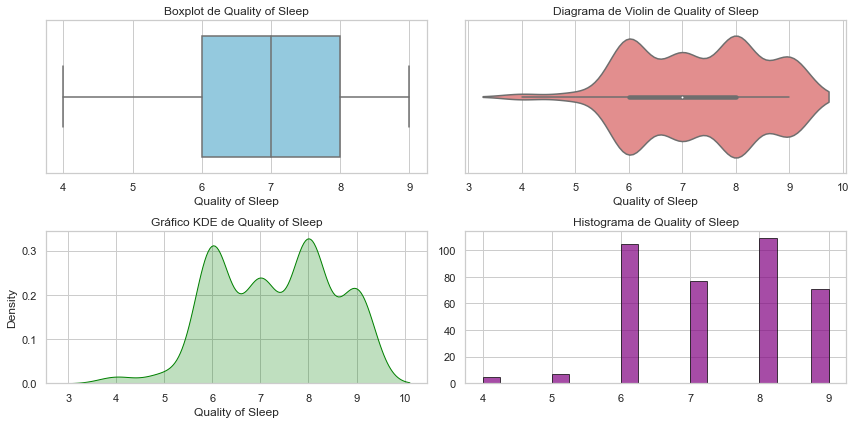

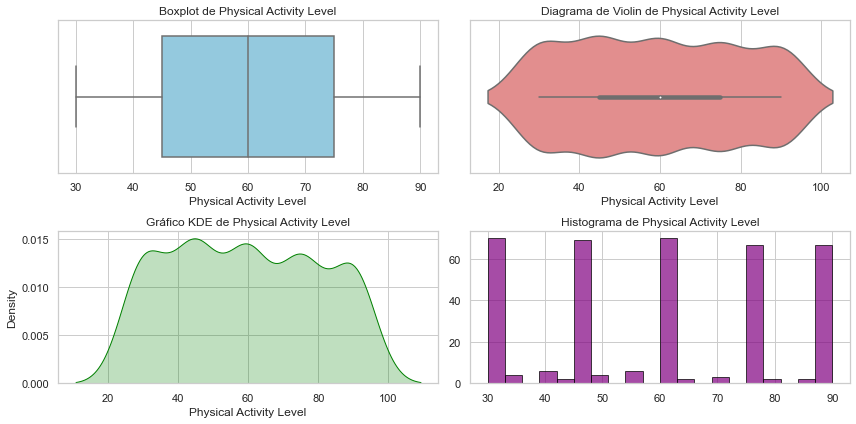

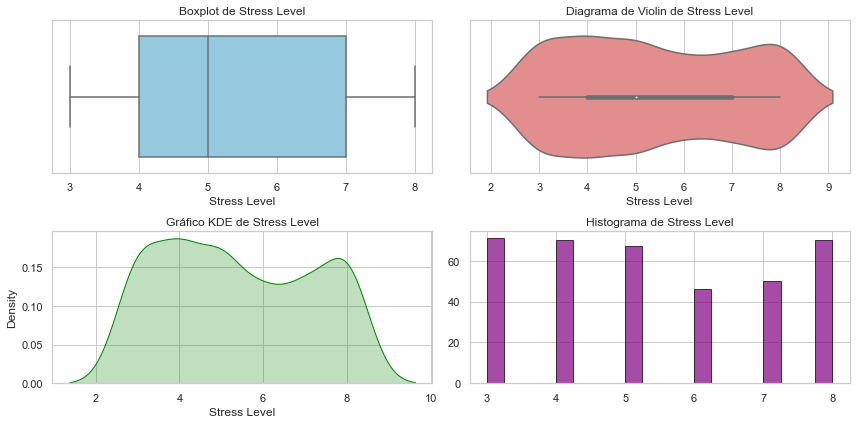

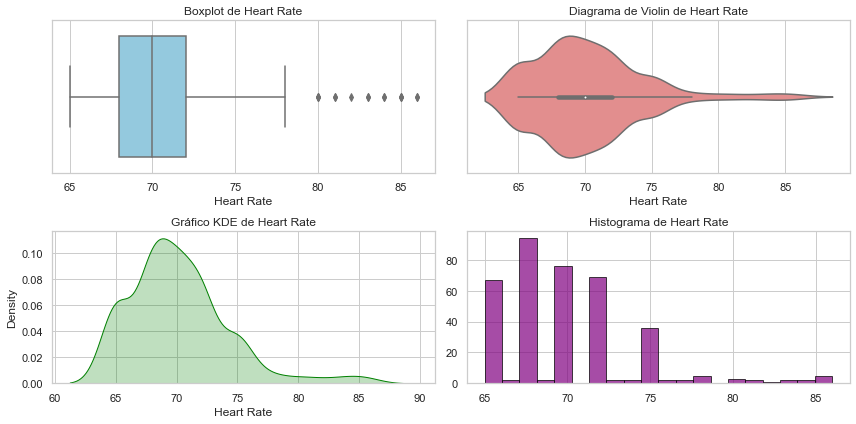

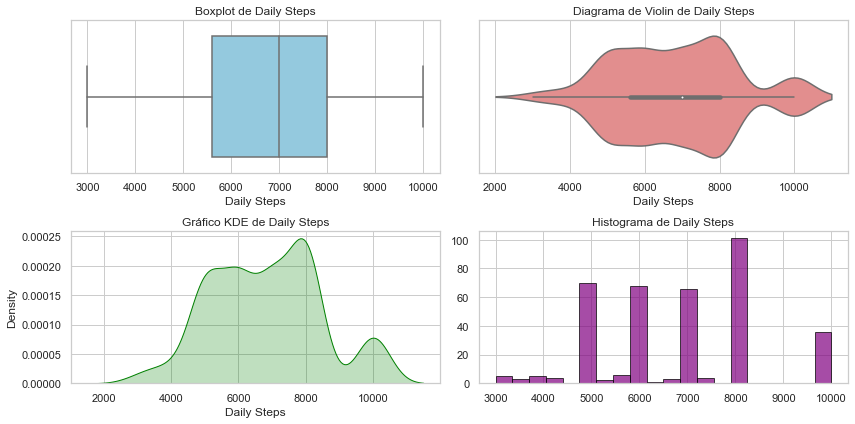

In [11]:
# Definir las variables numéricas
numerical_columns = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 
                     'Stress Level', 'Heart Rate', 'Daily Steps']

# Crear los gráficos
for col in numerical_columns:
    plt.figure(figsize=(12, 6))
    
    # Boxplot con hue
    plt.subplot(2, 2, 1)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot de {col}")

    # Violin plot
    plt.subplot(2, 2, 2)
    sns.violinplot(x=df[col], color="lightcoral")
    plt.title(f"Diagrama de Violin de {col}")

    # KDE plot
    plt.subplot(2, 2, 3)
    sns.kdeplot(df[col], fill=True, color="green")
    plt.title(f"Gráfico KDE de {col}")

    # Histograma
    plt.subplot(2, 2, 4)
    plt.hist(df[col], bins=20, color="purple", alpha=0.7, edgecolor="black")
    plt.title(f"Histograma de {col}")

    plt.tight_layout()
    plt.show()

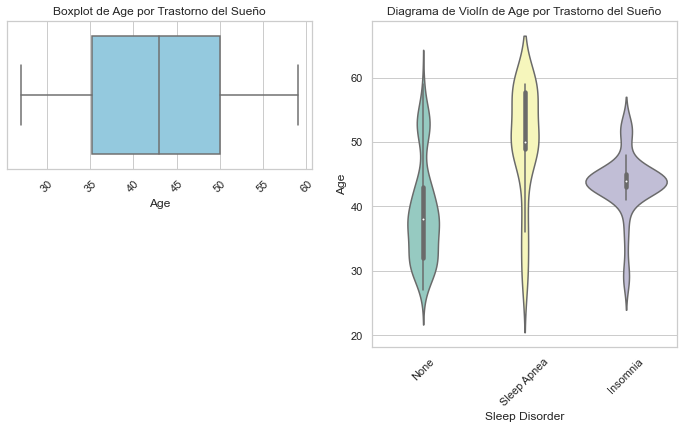

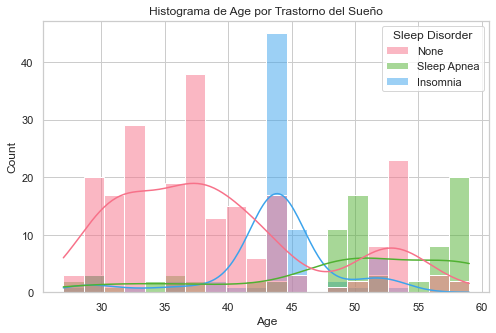

<Figure size 432x288 with 0 Axes>

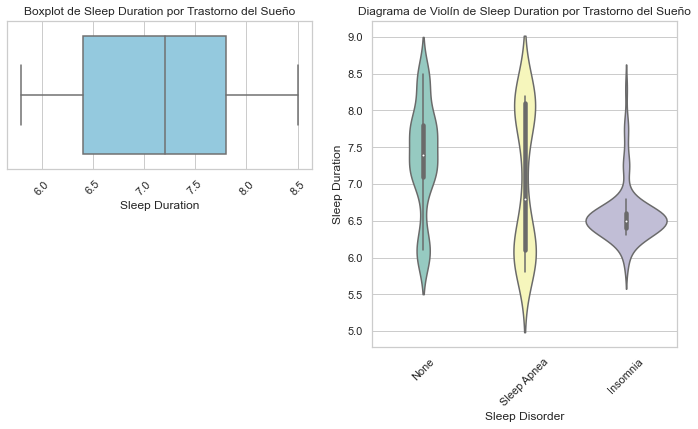

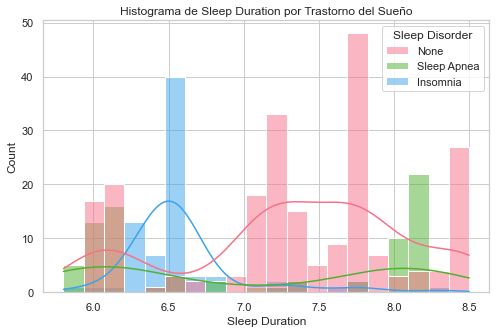

<Figure size 432x288 with 0 Axes>

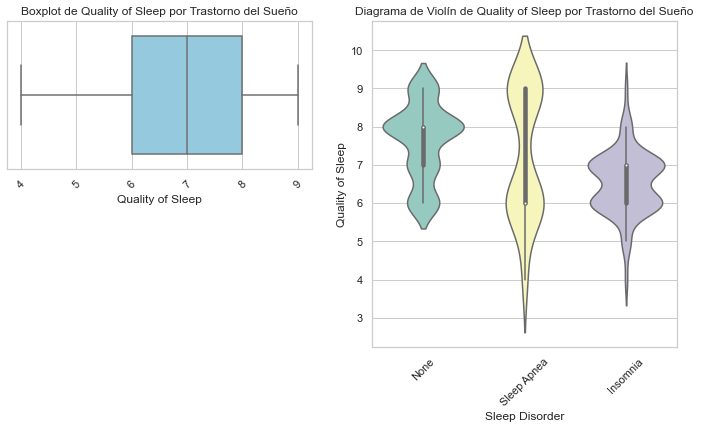

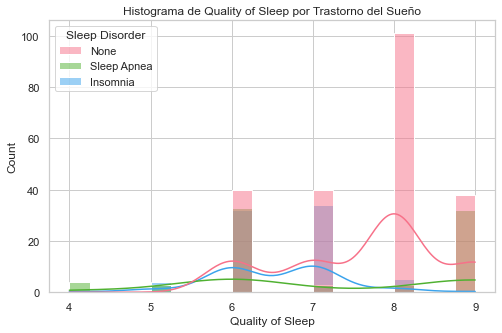

<Figure size 432x288 with 0 Axes>

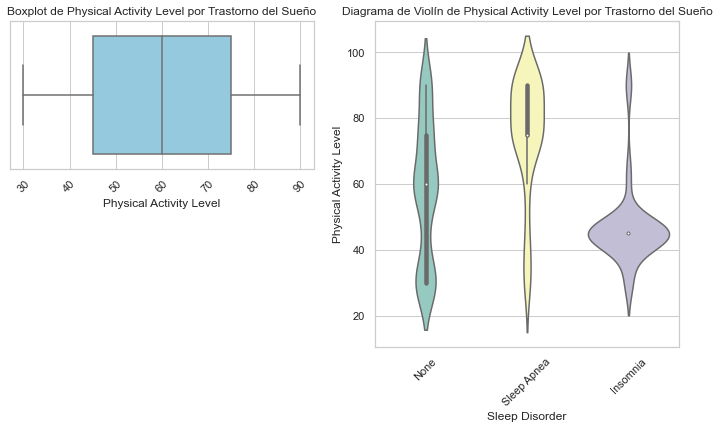

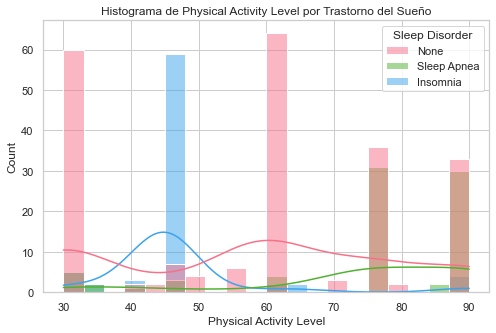

<Figure size 432x288 with 0 Axes>

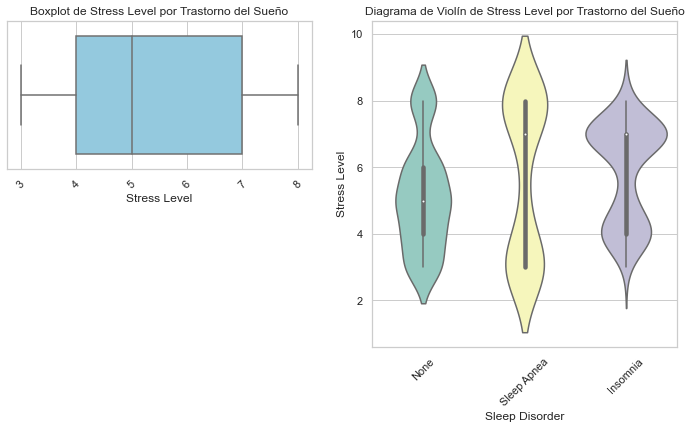

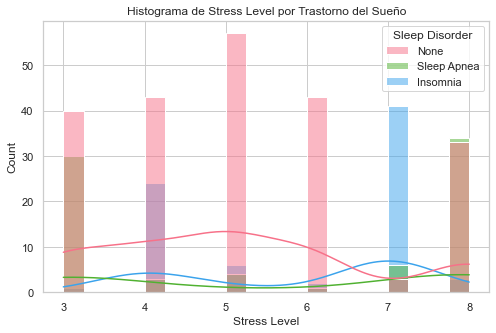

<Figure size 432x288 with 0 Axes>

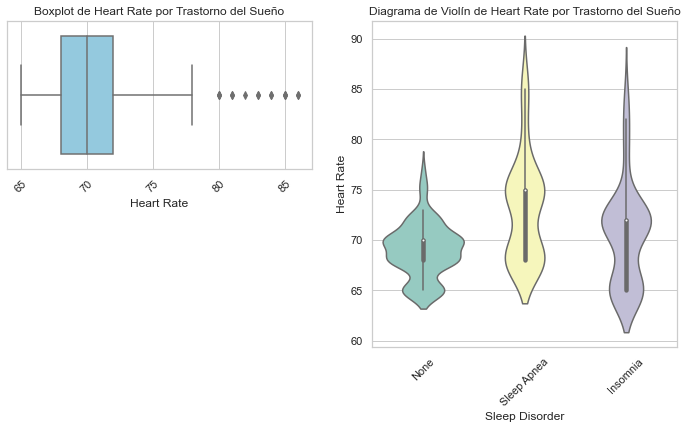

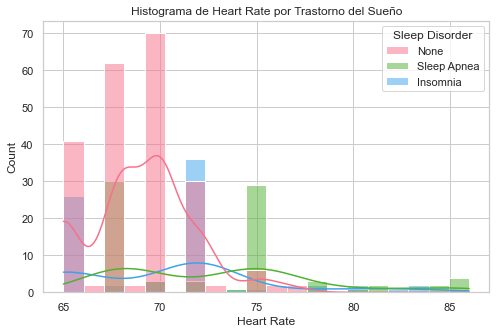

<Figure size 432x288 with 0 Axes>

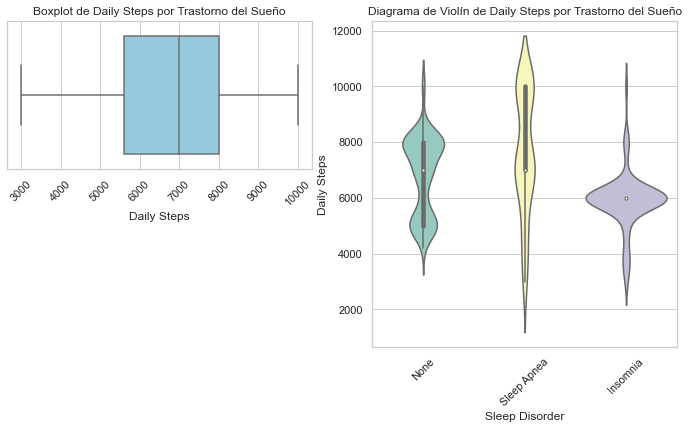

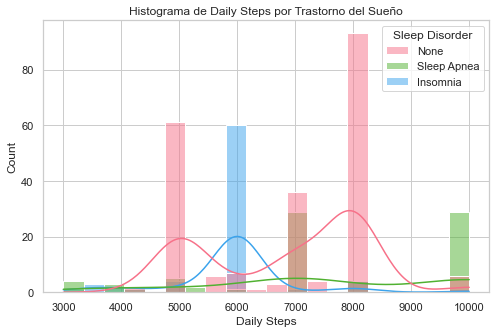

<Figure size 432x288 with 0 Axes>

In [12]:
# DIFERENCIANDO POR TRASTORNOS DEL SUEÑO
for col in numerical_columns:
    plt.figure(figsize=(12, 6))
    
    # Boxplot con hue
    plt.subplot(2, 2, 1)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot de {col} por Trastorno del Sueño")
    plt.xticks(rotation=45)
    
    # Violin Plot con hue
    plt.subplot(1, 2, 2)
    sns.violinplot(x=df["Sleep Disorder"], y=df[col], palette="Set3")
    plt.title(f"Diagrama de Violín de {col} por Trastorno del Sueño")
    plt.xticks(rotation=45)
    
    # Histograma con hue
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, hue="Sleep Disorder", kde=True, bins=20, palette="husl")
    plt.title(f"Histograma de {col} por Trastorno del Sueño")
    plt.show()
    

    plt.tight_layout()
    plt.show()

B) VARIABLES CATEGÓRICAS

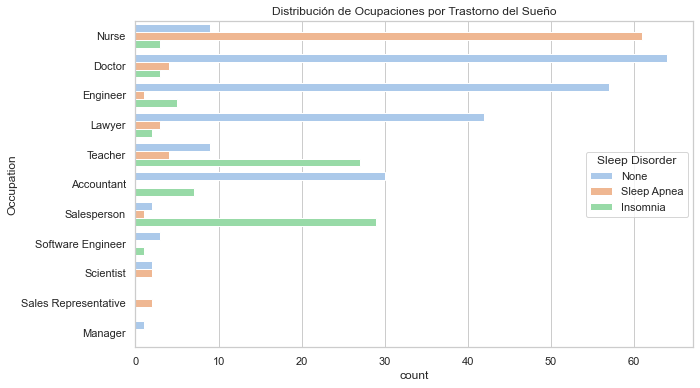

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(y=df["Occupation"], hue=df["Sleep Disorder"], palette="pastel", order=df["Occupation"].value_counts().index)
plt.title("Distribución de Ocupaciones por Trastorno del Sueño")
plt.show()

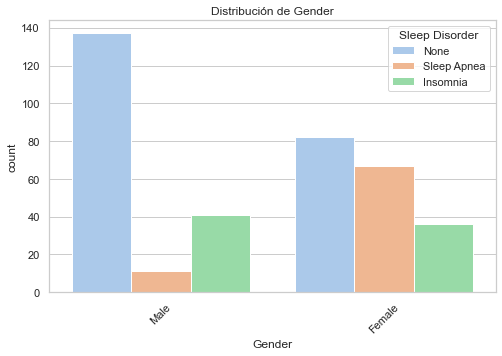

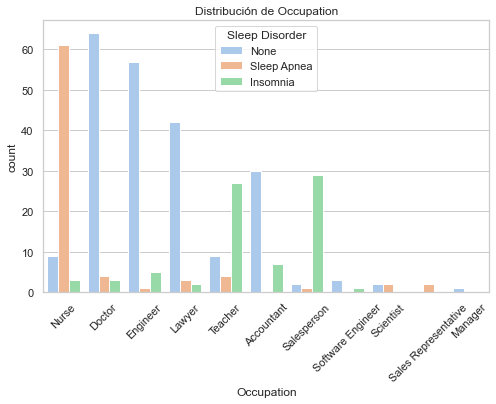

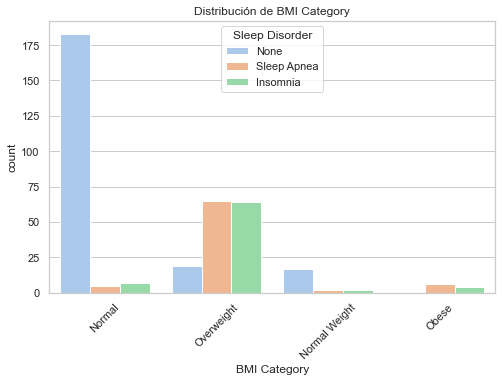

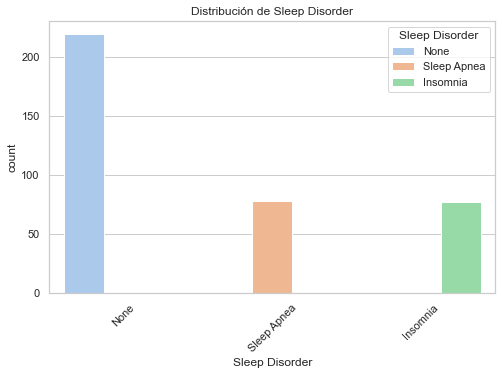

In [14]:
# Definir las variables categóricas
categorical_columns = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for col in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[col], hue=df["Sleep Disorder"], palette="pastel", order=df[col].value_counts().index)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)  # Girar etiquetas si es necesario
    plt.show()


OUTLIERS

In [15]:
# Detectar outliers en variables numéricas usando el método IQR
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 
                  'Physical Activity Level', 'Stress Level', 
                  'Heart Rate', 'Daily Steps']

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Definir umbrales para detectar outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Contar cuántos outliers hay por variable
outliers_count = ((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound)).sum()
print("Número de outliers por variable:\n", outliers_count)

# Identificar las filas con outliers sin eliminarlas
outliers = df[((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound)).any(axis=1)]
print(f"Número total de filas con al menos un outlier: {outliers.shape[0]}")


Número de outliers por variable:
 Age                         0
Sleep Duration              0
Quality of Sleep            0
Physical Activity Level     0
Stress Level                0
Heart Rate                 15
Daily Steps                 0
dtype: int64
Número total de filas con al menos un outlier: 15


## 3. CONVERSIÓN DE VARIABLES CATEGÓRICAS

- Se utilizará **Label Encoding** en las variables categóricas que sean de tipo **ordinal**, es decir, en aquellas en las que el peso cobra relevancia.
- **One-Hot Encoding** se utilizará para variables categóricas que sean binarias o que no tenga ningún "peso" el valor de la misma (variables **nominales**, sin orden).

https://www.analyticsvidhya.com/blog/2020/03/one-hot-encoding-vs-label-encoding-using-scikit-learn/#h-what-is-label-encoding

3.1 ONE-HOT ENCODING PARA VARIABLES NOMINALES

In [16]:
from sklearn.preprocessing import OneHotEncoder

# Variables nominales a transformar
nominal_cols = ['Gender', 'Occupation']

encoder = OneHotEncoder(drop='first', sparse=False)  # Elimina una categoría para evitar colinealidad
encoded_nominal = pd.DataFrame(encoder.fit_transform(df[nominal_cols]), 
                               columns=encoder.get_feature_names_out(nominal_cols))

# Concatenamos al dataframe y eliminamos las columnas originales
df = pd.concat([df.drop(columns=nominal_cols), encoded_nominal], axis=1)


C:\Users\Marina\anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


3.2 LABEL ENCODING PARA VARIABLES ORDINALES

In [17]:
df.head(30)

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,1,27,6.1,6,42,6,Overweight,126/83,77,4200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,28,6.2,6,60,8,Normal,125/80,75,10000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,28,6.2,6,60,8,Normal,125/80,75,10000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,28,5.9,4,30,8,Obese,140/90,85,3000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5,28,5.9,4,30,8,Obese,140/90,85,3000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,6,28,5.9,4,30,8,Obese,140/90,85,3000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,7,29,6.3,6,40,7,Obese,140/90,82,3500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7,8,29,7.8,7,75,6,Normal,120/80,70,8000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9,29,7.8,7,75,6,Normal,120/80,70,8000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10,29,7.8,7,75,6,Normal,120/80,70,8000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
print(df['BMI Category'].unique())

['Overweight' 'Normal' 'Obese' 'Normal Weight']


In [19]:
from sklearn.preprocessing import LabelEncoder

# Mapeo manual para asegurarnos del orden correcto
bmi_mapping = {'Normal Weight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
df['BMI Category'] = df['BMI Category'].map(bmi_mapping)

In [20]:
df.columns

Index(['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category',
       'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse',
       'Occupation_Sales Representative', 'Occupation_Salesperson',
       'Occupation_Scientist', 'Occupation_Software Engineer',
       'Occupation_Teacher'],
      dtype='object')

In [21]:
print(df.columns)

Index(['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category',
       'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse',
       'Occupation_Sales Representative', 'Occupation_Salesperson',
       'Occupation_Scientist', 'Occupation_Software Engineer',
       'Occupation_Teacher'],
      dtype='object')


In [22]:
# Ver valores nulos en el dataset
print("\nValores nulos en cada columna:")
print(df.isnull().sum())


Valores nulos en cada columna:
Person ID                          0
Age                                0
Sleep Duration                     0
Quality of Sleep                   0
Physical Activity Level            0
Stress Level                       0
BMI Category                       0
Blood Pressure                     0
Heart Rate                         0
Daily Steps                        0
Sleep Disorder                     0
Gender_Male                        0
Occupation_Doctor                  0
Occupation_Engineer                0
Occupation_Lawyer                  0
Occupation_Manager                 0
Occupation_Nurse                   0
Occupation_Sales Representative    0
Occupation_Salesperson             0
Occupation_Scientist               0
Occupation_Software Engineer       0
Occupation_Teacher                 0
dtype: int64


CONVERTIMOS LA PRESIÓN ARTERIAL EN VALORES NUMÉRICOS SEPARADOS

La presión sanguínea en el dataset está en una única celda, por lo que tenemos que dividirla en **sistólica** y **diastólica** y convertirla en tipo numérica.

In [23]:
 # División de las presiones en dos columnas:
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True)
    
# Conversión en tipo numérico
df[['Systolic BP', 'Diastolic BP']] = df[['Systolic BP', 'Diastolic BP']].apply(pd.to_numeric)
    
# eliminamos la columna inicial de las presiones
df = df.drop('Blood Pressure', axis=1)

In [24]:
df.head()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Systolic BP,Diastolic BP
0,1,27,6.1,6,42,6,2,77,4200,None,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,126,83
1,2,28,6.2,6,60,8,1,75,10000,None,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,125,80
2,3,28,6.2,6,60,8,1,75,10000,None,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,125,80
3,4,28,5.9,4,30,8,3,85,3000,Sleep Apnea,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,140,90
4,5,28,5.9,4,30,8,3,85,3000,Sleep Apnea,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,140,90


ESCALAR LAS VARIABLES NUMÉRICAS

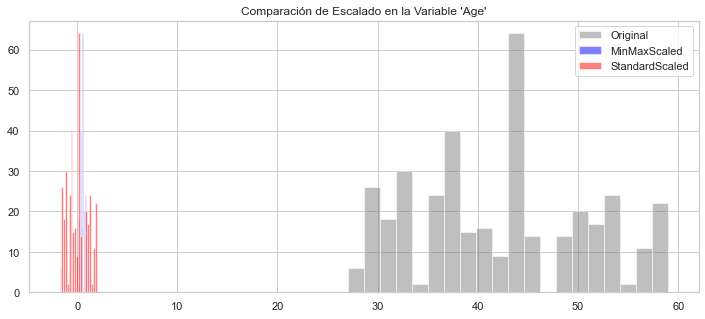

----- Datos Originales -----
              Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
count  374.000000      374.000000        374.000000               374.000000   
mean    42.184492        7.132086          7.312834                59.171123   
std      8.673133        0.795657          1.196956                20.830804   
min     27.000000        5.800000          4.000000                30.000000   
25%     35.250000        6.400000          6.000000                45.000000   
50%     43.000000        7.200000          7.000000                60.000000   
75%     50.000000        7.800000          8.000000                75.000000   
max     59.000000        8.500000          9.000000                90.000000   

       Stress Level  Heart Rate   Daily Steps  Systolic BP  Diastolic BP  
count    374.000000  374.000000    374.000000   374.000000    374.000000  
mean       5.385027   70.165775   6816.844920   128.553476     84.649733  
std        1.774526    4.

In [25]:
from sklearn.preprocessing import MinMaxScaler
# Seleccionar solo las columnas numéricas a escalar
columnas_numericas = ["Age", "Sleep Duration", "Quality of Sleep", "Physical Activity Level", 
                       "Stress Level", "Heart Rate", "Daily Steps", "Systolic BP", "Diastolic BP"]

# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[columnas_numericas] = minmax_scaler.fit_transform(df[columnas_numericas])

# Aplicar StandardScaler
standard_scaler = StandardScaler()
df_standard = df.copy()
df_standard[columnas_numericas] = standard_scaler.fit_transform(df[columnas_numericas])

# Comparar histogramas de una variable (ejemplo: 'Age')
plt.figure(figsize=(12,5))
plt.hist(df[columnas_numericas]["Age"], bins=20, alpha=0.5, label="Original", color="gray")
plt.hist(df_minmax[columnas_numericas]["Age"], bins=20, alpha=0.5, label="MinMaxScaled", color="blue")
plt.hist(df_standard[columnas_numericas]["Age"], bins=20, alpha=0.5, label="StandardScaled", color="red")
plt.legend()
plt.title("Comparación de Escalado en la Variable 'Age'")
plt.show()

# Mostrar estadísticas básicas
print("----- Datos Originales -----")
print(df[columnas_numericas].describe())

print("\n----- MinMaxScaler -----")
print(df_minmax[columnas_numericas].describe())

print("\n----- StandardScaler -----")
print(df_standard[columnas_numericas].describe())

Utilizamos MinMaxScaler porque tenemos diferentes escalas (edad en años, presión arterial en mmHg)

Además el otro nos da números negativos y luego no podemos trabajar con ellos

In [26]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
            'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# vemos el resultado
df.head()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Systolic BP,Diastolic BP
0,1,0.00000,0.111111,0.4,0.2,0.6,2,0.571429,0.171429,None,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.407407,0.40
1,2,0.03125,0.148148,0.4,0.5,1.0,1,0.476190,1.000000,None,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.370370,0.25
2,3,0.03125,0.148148,0.4,0.5,1.0,1,0.476190,1.000000,None,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.370370,0.25
3,4,0.03125,0.037037,0.0,0.0,1.0,3,0.952381,0.000000,Sleep Apnea,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.925926,0.75
4,5,0.03125,0.037037,0.0,0.0,1.0,3,0.952381,0.000000,Sleep Apnea,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.925926,0.75


## 4. ANÁLISIS DE CORRELACIONES

Ver si las correlaciones son de tipo lineal o no.

<ipython-input-27-b1461fdf490c>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")


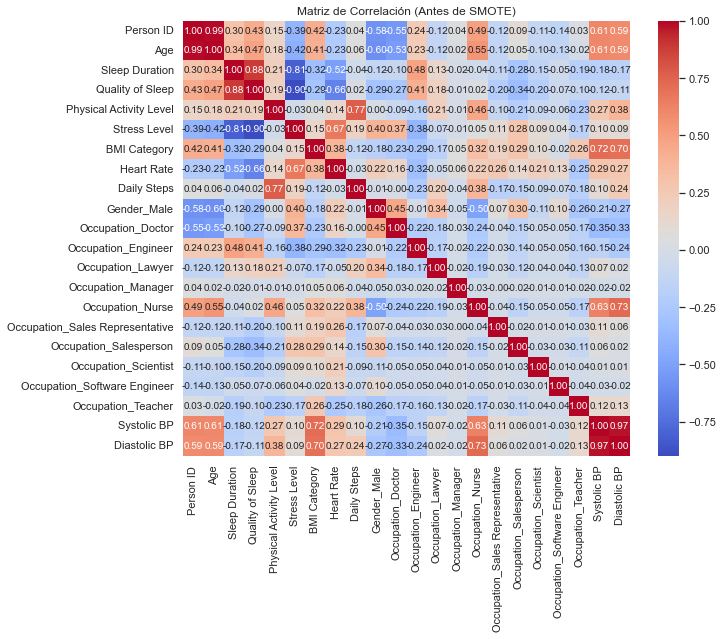

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación (Antes de SMOTE)")
plt.show()

<ipython-input-28-d4af45c16b2b>:6: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


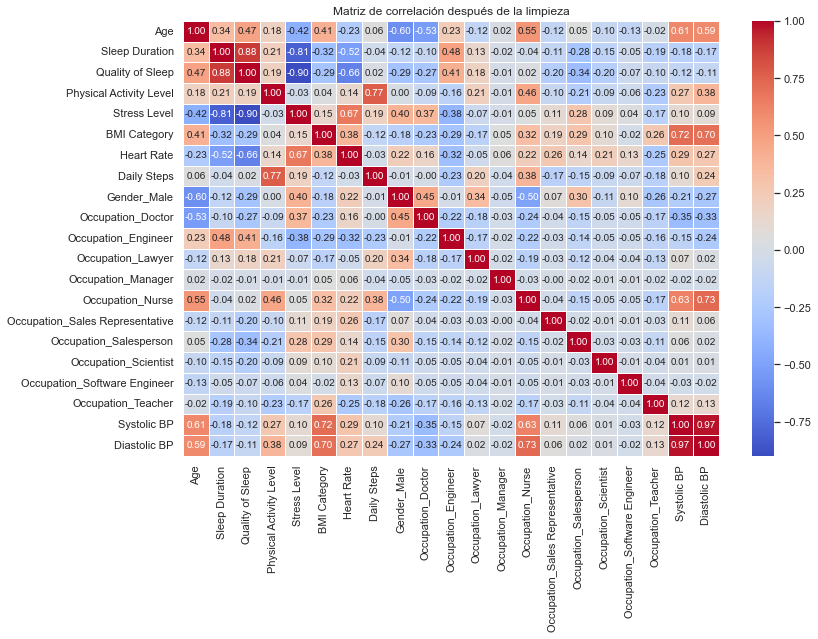

In [28]:
# Eliminamos las variables con alta correlación
df = df.drop(columns=['Person ID']) 

# Volvemos a graficar la matriz de correlación
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación después de la limpieza")
plt.show()


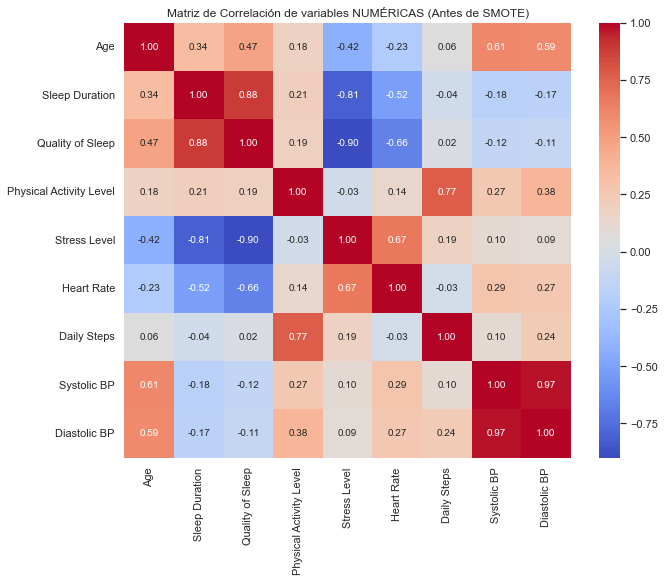

In [29]:
## VARIABLES NUMÉRICAS
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de variables NUMÉRICAS (Antes de SMOTE)")
plt.show()

## 5. SELECCIÓN DE CARACTERÍSTICAS

In [30]:
# Ver valores nulos en el dataset
print("\nValores nulos en cada columna:")
print(df.isnull().sum())


Valores nulos en cada columna:
Age                                0
Sleep Duration                     0
Quality of Sleep                   0
Physical Activity Level            0
Stress Level                       0
BMI Category                       0
Heart Rate                         0
Daily Steps                        0
Sleep Disorder                     0
Gender_Male                        0
Occupation_Doctor                  0
Occupation_Engineer                0
Occupation_Lawyer                  0
Occupation_Manager                 0
Occupation_Nurse                   0
Occupation_Sales Representative    0
Occupation_Salesperson             0
Occupation_Scientist               0
Occupation_Software Engineer       0
Occupation_Teacher                 0
Systolic BP                        0
Diastolic BP                       0
dtype: int64


A) FILTRADO BASADO EN CORRELACIÓN --> hay que corregir porque Sleep Disorder es categorica

In [31]:
# Umbral de correlación mínima con 'Sleep Disorder'
#umbral_min = 0.1  

# Correlaciones con la variable objetivo
#corr_target = df.corr()['Sleep Disorder'].abs()

# Variables que superan el umbral
#features_seleccionadas = corr_target[corr_target > umbral_min].index.tolist()

#print("Características seleccionadas:", features_seleccionadas)

In [32]:
# NO SE DONDE TIENE QUE IR ESTO
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop(columns=['Sleep Disorder'])  # Variables independientes
y = df['Sleep Disorder']  # Variable dependiente

selector = SelectKBest(f_classif, k=10)  # Seleccionar las 10 mejores características
X_selected = selector.fit_transform(X, y)

B) FEATURE IMPORTANCE CON RANDOM FOREST

Evalúa la importancia de cada variable basándose en cómo afectan a la predicción

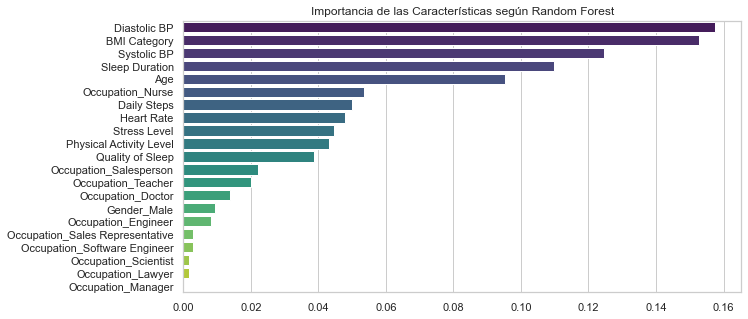

In [33]:
# PRUEBA!!! IMPORTANCIA CARACTERISTICAS
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# Separar características y variable objetivo
X = df.drop(columns=['Sleep Disorder'])  # Quitamos ID y target
y = df['Sleep Disorder']

# Entrenar modelo de Random Forest para ver importancia de variables
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Obtener importancia de características
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Visualizar la importancia de las variables
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title("Importancia de las Características según Random Forest")
plt.show()


In [34]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Separar variables predictoras y objetivo
X = df_filtrado.drop(columns=['Sleep Disorder'])
y = df_filtrado['Sleep Disorder']

# Entrenar Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Importancia de características
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Mostrar las más importantes
print(importances)

# Graficar importancia de características
importances.plot(kind='bar', title="Importancia de Características con Random Forest")
plt.show()


NameError: name 'df_filtrado' is not defined

C) SELECCIÓN SELECTKBEST con chi2

In [35]:
from sklearn.feature_selection import chi2, SelectKBest

# Asegurar que todas las variables sean numéricas
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder'].astype('category').cat.codes  # Convertimos temporalmente a numérico

# Aplicar prueba de chi2
selector = SelectKBest(chi2, k='all')  # Evaluamos todas las características
X_new = selector.fit_transform(X, y)

# Mostrar los valores de chi2
chi2_scores = selector.scores_
feature_names = X.columns

# Crear un DataFrame con los resultados
chi2_results = pd.DataFrame({'Feature': feature_names, 'Chi2 Score': chi2_scores})
chi2_results = chi2_results.sort_values(by='Chi2 Score', ascending=False)

# Mostrar las características ordenadas por importancia
print(chi2_results)


                            Feature  Chi2 Score
13                 Occupation_Nurse  173.900836
15           Occupation_Salesperson   96.015096
5                      BMI Category   55.986535
18               Occupation_Teacher   53.897596
20                     Diastolic BP   43.368515
19                      Systolic BP   32.819674
9                 Occupation_Doctor   29.217291
10              Occupation_Engineer   27.075301
8                       Gender_Male   26.862604
11                Occupation_Lawyer   18.427140
3           Physical Activity Level   17.778100
0                               Age   13.828096
1                    Sleep Duration    9.637225
6                        Heart Rate    8.870234
14  Occupation_Sales Representative    7.589744
7                       Daily Steps    4.305998
2                  Quality of Sleep    4.178586
4                      Stress Level    3.385740
16             Occupation_Scientist    2.502634
17     Occupation_Software Engineer    1

- Un **Chi2 Score alto** indica una mayor relación con *Sleep Disorder*
- Las variables más influyentes son:
    - Occupation_Nurse (173.9)
    - Occupation_Salesperson (96.0)
    - BMI Category (55.9)
    - Occupation_Teacher (53.8)
    - Diastolic BP (43.3)

Esto sugiere que la **ocupación** y el **BMI Category** tienen una fuerte relación con el trastorno del sueño

D) SELECCIÓN RECURSIVA DE CARACTERÍSTICAS (RFE)

Utiliza un modelo para ir eliminando las características menos relevantes de manera iterativa.

In [36]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Modelo base (puede ser otro)
model = LogisticRegression(max_iter=1000)

# Aplicar RFE para seleccionar las 5 mejores características
selector = RFE(model, n_features_to_select=5, step=1)
selector = selector.fit(X, y)

# Variables seleccionadas
selected_features = X.columns[selector.support_]
print("Características seleccionadas con RFE:", selected_features)


Características seleccionadas con RFE: Index(['Age', 'Sleep Duration', 'Heart Rate', 'Occupation_Nurse',
       'Diastolic BP'],
      dtype='object')


SELECCIÓN BASADA EN MÉTODOS ESTADÍSTICOS

Si *Sleep Disorder* es categórica, usamos **chi-cuadrado**; si es numérica, usamos **ANOVA**.

In [37]:
X.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Gender_Male,Occupation_Doctor,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Systolic BP,Diastolic BP
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,...,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,0.474515,0.493365,0.662567,0.486185,0.477005,1.393048,0.245989,0.545264,0.505348,0.189840,...,0.125668,0.002674,0.195187,0.005348,0.085561,0.010695,0.010695,0.106952,0.501981,0.482487
std,0.271035,0.294688,0.239391,0.347180,0.354905,0.636727,0.196937,0.231131,0.500641,0.392699,...,0.331919,0.051709,0.396876,0.073029,0.280090,0.103001,0.103001,0.309466,0.286967,0.308081
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.257812,0.222222,0.400000,0.250000,0.200000,1.000000,0.142857,0.371429,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.370370,0.250000
50%,0.500000,0.518519,0.600000,0.500000,0.400000,1.000000,0.238095,0.571429,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.555556,0.500000
75%,0.718750,0.740741,0.800000,0.750000,0.800000,2.000000,0.333333,0.714286,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.740741,0.750000
max,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [38]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Para variable categórica (Chi-cuadrado)
chi2_selector = SelectKBest(score_func=chi2, k=5)
chi2_selector.fit(X, y)

# Para variable numérica (ANOVA)
anova_selector = SelectKBest(score_func=f_classif, k=5)
anova_selector.fit(X, y)

# Mostrar resultados
print("Características seleccionadas con Chi-cuadrado:", X.columns[chi2_selector.get_support()])
print("Características seleccionadas con ANOVA:", X.columns[anova_selector.get_support()])


Características seleccionadas con Chi-cuadrado: Index(['BMI Category', 'Occupation_Nurse', 'Occupation_Salesperson',
       'Occupation_Teacher', 'Diastolic BP'],
      dtype='object')
Características seleccionadas con ANOVA: Index(['BMI Category', 'Occupation_Nurse', 'Occupation_Salesperson',
       'Systolic BP', 'Diastolic BP'],
      dtype='object')


### SMOTE ??? mirar si aqui esta bien del todo

In [39]:
X = df.drop(columns=['Sleep Disorder'])  # Sleep Disorder es la variable objetivo
y = df['Sleep Disorder']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
df_balanced = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.DataFrame(y_resampled, columns=['Sleep Disorder'])], axis=1)

ANÁLISIS DE DATOS DESBALANCEADOS

In [40]:
# Distribución de clases antes de SMOTE
print(df['Sleep Disorder'].value_counts(normalize=True) * 100)

None           58.556150
Sleep Apnea    20.855615
Insomnia       20.588235
Name: Sleep Disorder, dtype: float64


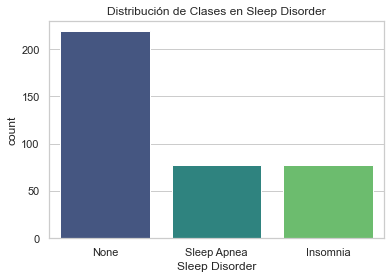

In [41]:
sns.countplot(x=y, palette="viridis")  # 'y' es la variable objetivo
plt.title("Distribución de Clases en Sleep Disorder")
plt.show()

In [42]:
# DESPUES DE SMOTE CONTAMOS CLASES
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_selected, y)

# Ver distribución después de SMOTE
print(pd.Series(y_resampled).value_counts(normalize=True) * 100)

None           33.333333
Sleep Apnea    33.333333
Insomnia       33.333333
Name: Sleep Disorder, dtype: float64


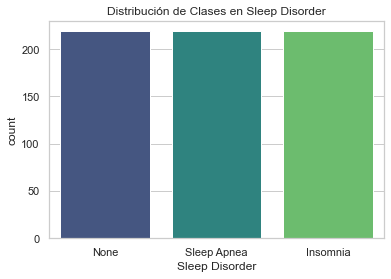

In [43]:
sns.countplot(x=y_resampled, palette="viridis")  # 'y' es la variable objetivo
plt.title("Distribución de Clases en Sleep Disorder")
plt.show()

## 6. MODELOS PREDICTIVOS

### DIVIDIMOS LOS DATOS EN ENTRENAMIENTO Y PRUEBA

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### EVALUACIÓN DE MODELOS PREDICTIVOS

Modelo: Logistic Regression

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       0.98      0.95      0.97        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.93        75
   macro avg       0.91      0.92      0.91        75
weighted avg       0.94      0.93      0.93        75

Matriz de confusión:


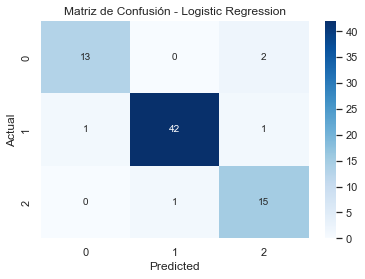



Modelo: Decision Tree

              precision    recall  f1-score   support

    Insomnia       0.87      0.87      0.87        15
        None       1.00      0.95      0.98        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.93        75
   macro avg       0.90      0.92      0.91        75
weighted avg       0.94      0.93      0.93        75

Matriz de confusión:


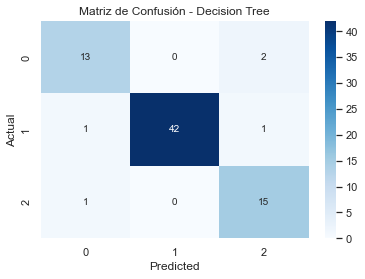



Modelo: SVM

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       0.93      0.95      0.94        44
 Sleep Apnea       0.88      0.88      0.88        16

    accuracy                           0.92        75
   macro avg       0.91      0.90      0.91        75
weighted avg       0.92      0.92      0.92        75

Matriz de confusión:


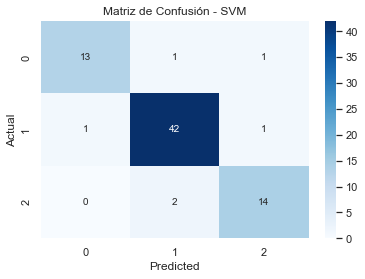



Modelo: MLP

              precision    recall  f1-score   support

    Insomnia       1.00      0.87      0.93        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.84      1.00      0.91        16

    accuracy                           0.96        75
   macro avg       0.95      0.95      0.94        75
weighted avg       0.97      0.96      0.96        75

Matriz de confusión:


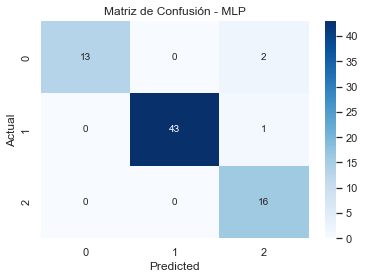



Modelo: Random Forest

              precision    recall  f1-score   support

    Insomnia       0.87      0.87      0.87        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75

Matriz de confusión:


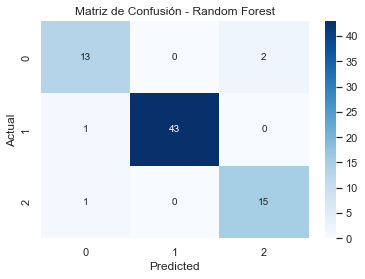

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Diccionario de modelos a evaluar
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True),
    "MLP": MLPClassifier(max_iter=1000),
    "Random Forest": RandomForestClassifier()
}

# Entrenar y evaluar cada modelo
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)  # Entrenamiento
    y_pred = model.predict(X_test)  # Predicción
    
    # Guardar resultados
    results[name] = {
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    
    # Mostrar resultados
    print(f"Modelo: {name}\n")
    print(classification_report(y_test, y_pred))
    print("Matriz de confusión:")
    sns.heatmap(results[name]["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    print("\n" + "="*50 + "\n")


Tras la implementación de varios modelos, se han evaluacdo las métricas básicas para escoger los mejores y llevar a cabo la optimización de hiperparámetros.

### COMPARACIÓN DE MODELOS CON Y SIN SMOTE

In [46]:
pip install imbalanced-learn

Distribución original: Counter({'None': 175, 'Sleep Apnea': 62, 'Insomnia': 62})
Distribución después de SMOTE: Counter({'None': 175, 'Sleep Apnea': 175, 'Insomnia': 175})
Modelo: Logistic Regression (con SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      0.93      0.96        44
 Sleep Apnea       0.80      1.00      0.89        16

    accuracy                           0.93        75
   macro avg       0.91      0.93      0.92        75
weighted avg       0.94      0.93      0.93        75

Matriz de confusión:


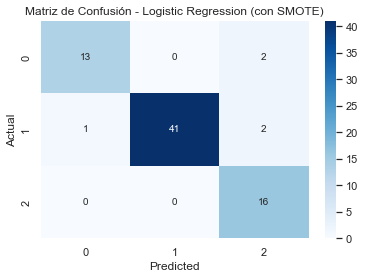



Modelo: Decision Tree (con SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.72      0.87      0.79        15
        None       1.00      0.95      0.98        44
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.91        75
   macro avg       0.86      0.88      0.87        75
weighted avg       0.92      0.91      0.91        75

Matriz de confusión:


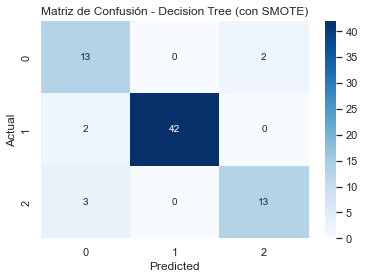



Modelo: SVM (con SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.92      0.80      0.86        15
        None       1.00      0.93      0.96        44
 Sleep Apnea       0.76      1.00      0.86        16

    accuracy                           0.92        75
   macro avg       0.89      0.91      0.90        75
weighted avg       0.93      0.92      0.92        75

Matriz de confusión:


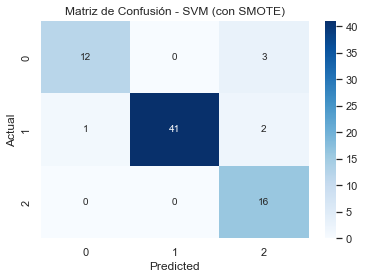



Modelo: MLP (con SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       0.96      0.98      0.97        44
 Sleep Apnea       0.81      0.81      0.81        16

    accuracy                           0.92        75
   macro avg       0.90      0.89      0.89        75
weighted avg       0.92      0.92      0.92        75

Matriz de confusión:


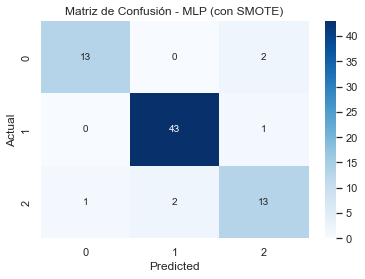



Modelo: Random Forest (con SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.72      0.87      0.79        15
        None       1.00      0.95      0.98        44
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.91        75
   macro avg       0.86      0.88      0.87        75
weighted avg       0.92      0.91      0.91        75

Matriz de confusión:


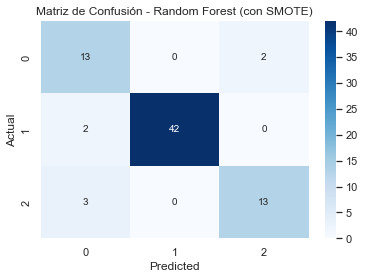

In [47]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Aplicamos SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Ver la nueva distribución de clases
print("Distribución original:", Counter(y_train))
print("Distribución después de SMOTE:", Counter(y_train_smote))

# Diccionario de modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True),
    "MLP": MLPClassifier(max_iter=1000),
    "Random Forest": RandomForestClassifier()
}

# Entrenar y evaluar cada modelo con SMOTE
results_smote = {}
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)  # Entrenamiento con datos balanceados
    y_pred_smote = model.predict(X_test)  # Predicción
    
    # Guardar resultados
    results_smote[name] = {
        "classification_report": classification_report(y_test, y_pred_smote, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred_smote)
    }
    
    # Mostrar resultados
    print(f"Modelo: {name} (con SMOTE)\n")
    print(classification_report(y_test, y_pred_smote))
    print("Matriz de confusión:")
    sns.heatmap(results_smote[name]["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusión - {name} (con SMOTE)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    print("\n" + "="*50 + "\n")


### AJUSTE DE HIPERPARÁMETROS

1) RANDOM FOREST

Parámtros a ajustar:
- n_estimators
- max_depth
- min_samples_split, min_samples_leaf

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Definir el modelo
rf = RandomForestClassifier(random_state=42)

# Definir el espacio de búsqueda de hiperparámetros
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Configurar la búsqueda aleatoria
rf_random = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=20,  # Número de combinaciones a probar
    cv=5,  # Validación cruzada
    verbose=2, 
    random_state=42, 
    n_jobs=-1
)

# Ajustar el modelo a los datos de entrenamiento (X_train, y_train deben estar definidos)
rf_random.fit(X_train, y_train)

# Mejor combinación de hiperparámetros encontrada
print("Mejores hiperparámetros para Random Forest:", rf_random.best_params_)

# Evaluación en los datos de prueba (X_test, y_test deben estar definidos)
y_pred = rf_random.best_estimator_.predict(X_test)

from sklearn.metrics import classification_report
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros para Random Forest: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}
Reporte de clasificación:
               precision    recall  f1-score   support

    Insomnia       0.93      0.93      0.93        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.97        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.97      0.97      0.97        75



2) DECISION TREE

Parámetros a ajustar:
- max_depth
- min_samples_split
- min_samples_leaf

In [49]:
from sklearn.model_selection import GridSearchCV
# Definir el modelo Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Definir el espacio de búsqueda de hiperparámetros para Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Configurar la búsqueda de cuadrícula para Decision Tree
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Ajustar el modelo a los datos de entrenamiento
dt_grid.fit(X_train, y_train)

# Mejor combinación de hiperparámetros encontrada para Decision Tree
print("Mejores hiperparámetros para Decision Tree:", dt_grid.best_params_)

# Evaluación en los datos de prueba para Decision Tree
dt_y_pred = dt_grid.best_estimator_.predict(X_test)
print("Reporte de clasificación para Decision Tree:\n", classification_report(y_test, dt_y_pred))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores hiperparámetros para Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Reporte de clasificación para Decision Tree:
               precision    recall  f1-score   support

    Insomnia       1.00      0.80      0.89        15
        None       0.96      0.98      0.97        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.93        75
   macro avg       0.93      0.90      0.91        75
weighted avg       0.94      0.93      0.93        75



3) MLP 

Parámtros a ajustar:

- hidden_layer_sizes
- activation
- alpha
- learning_rate_init 


In [50]:
# Definir el modelo MLP
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Definir el espacio de búsqueda de hiperparámetros para MLP
param_dist_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

# Configurar la búsqueda aleatoria para MLP
mlp_random = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist_mlp,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Ajustar el modelo a los datos de entrenamiento
mlp_random.fit(X_train, y_train)

# Mejor combinación de hiperparámetros encontrada para MLP
print("Mejores hiperparámetros para MLP:", mlp_random.best_params_)

# Evaluación en los datos de prueba para MLP
mlp_y_pred = mlp_random.best_estimator_.predict(X_test)
print("Reporte de clasificación para MLP:\n", classification_report(y_test, mlp_y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros para MLP: {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (50,), 'alpha': 0.01, 'activation': 'tanh'}
Reporte de clasificación para MLP:
               precision    recall  f1-score   support

    Insomnia       1.00      0.93      0.97        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.89      1.00      0.94        16

    accuracy                           0.97        75
   macro avg       0.96      0.97      0.97        75
weighted avg       0.98      0.97      0.97        75



4) LOGISTIC REGRESSION

Parámtros a ajustar:
- c (regularización)
- solver (método de optimización)

In [51]:
# Definir el modelo Logist Regression
log_reg = LogisticRegression(max_iter=5000)

# Definir la cuadrícula de hiperparámetros
param_grid = {
    'penalty': ['l1', 'l2'],
    'C':  [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
}

# Realizar la búsqueda con validación cruzada
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros y evaluar en el test set
print("Mejores hiperparámetros para Logistic Regression:", grid_search.best_params_)

# Evaluación en test set
best_log_reg = grid_search.best_estimator_
y_pred = best_log_reg.predict(X_test)
print("Reporte de clasificación para Logistic Regression:\n", classification_report(y_test, y_pred))

Mejores hiperparámetros para Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Reporte de clasificación para Logistic Regression:
               precision    recall  f1-score   support

    Insomnia       0.93      0.93      0.93        15
        None       1.00      0.95      0.98        44
 Sleep Apnea       0.89      1.00      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.96      0.95        75
weighted avg       0.96      0.96      0.96        75



- Random Forest → accuracy: 0.96 | f1-score promedio: 0.94
- Decision Tree → accuracy: 0.95 | f1-score promedio: 0.93
- SVM → accuracy: 0.95 | f1-score promedio: 0.91
- MLP → accuracy: 0.93 | f1-score promedio: 0.90
- Regresión Logística → accuracy: 0.92 | f1-score promedio: 0.89

5) SVM

Parámetros a ajustar:
- Parámetro C (regularización)
- kernel --> tipo de kernel
- gamma --> (para kernels RBF y polinómicos)


In [52]:
# Definir el modelo SVM
svm = SVC(random_state=42)

# Definir el espacio de búsqueda de hiperparámetros para SVM
param_dist_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Configurar la búsqueda aleatoria para SVM
svm_random = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist_svm,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Ajustar el modelo a los datos de entrenamiento
svm_random.fit(X_train, y_train)

# Mejor combinación de hiperparámetros encontrada para SVM
print("Mejores hiperparámetros para SVM:", svm_random.best_params_)

# Evaluación en los datos de prueba para SVM
svm_y_pred = svm_random.best_estimator_.predict(X_test)
print("Reporte de clasificación para SVM:\n", classification_report(y_test, svm_y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros para SVM: {'kernel': 'poly', 'gamma': 'scale', 'C': 0.1}
Reporte de clasificación para SVM:
               precision    recall  f1-score   support

    Insomnia       0.82      0.93      0.87        15
        None       0.93      0.98      0.96        44
 Sleep Apnea       1.00      0.75      0.86        16

    accuracy                           0.92        75
   macro avg       0.92      0.89      0.90        75
weighted avg       0.93      0.92      0.92        75



### CURVA ROC-AUC Y PRECISSION-RECALL

**Curva ROC (Receiver Operating Characteristic)**

La Curva ROC es una representación gráfica que evalúa el rendimiento de un modelo de clasificación binaria al mostrar la relación entre la Tasa de Verdaderos Positivos (True Positive Rate, TPR) y la Tasa de Falsos Positivos (False Positive Rate, FPR) a través de diferentes umbrales de decisión. Cada punto en la curva corresponde a un par (FPR, TPR) para un umbral específico. El área bajo la curva ROC, conocida como AUC (Area Under the Curve), proporciona una medida única del rendimiento general del modelo; un AUC cercano a 1 indica un modelo con alta capacidad discriminativa, mientras que un AUC cercano a 0.5 sugiere un rendimiento similar al azar. ​
DataScientest

- https://www.elsevier.es/es-revista-medicina-familia-semergen-40-articulo-la-curva-roc-S1138359322001952

- https://www.datacamp.com/es/tutorial/auc


**Curva Precision-Recall**

La Curva Precision-Recall es especialmente útil en escenarios donde las clases están desbalanceadas. Esta curva grafica la Precisión frente al Recall (Sensibilidad) para diferentes umbrales de decisión. La Precisión mide la proporción de predicciones positivas que son correctas, mientras que el Recall indica la proporción de verdaderos positivos identificados correctamente por el modelo. El área bajo esta curva proporciona una medida del rendimiento del modelo en contextos de clases desbalanceadas; un área más grande indica un mejor rendimiento. 


- https://www.datacamp.com/es/tutorial/precision-recall-curve-tutorial

REENTRENAMIENTO DE MODELOS

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True),
    "MLP": MLPClassifier(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)  # Asegúrate de que X_train e y_train existen
    trained_models[name] = model  # Guardamos el modelo correctamente

print("Modelos reentrenados correctamente.")


Modelos reentrenados correctamente.


Evaluando modelo: Logistic Regression


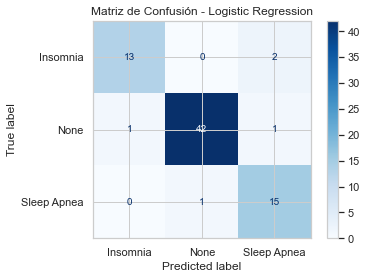

Evaluando modelo: Decision Tree


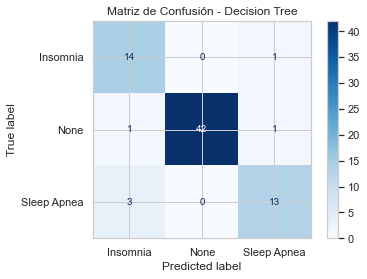

Evaluando modelo: SVM


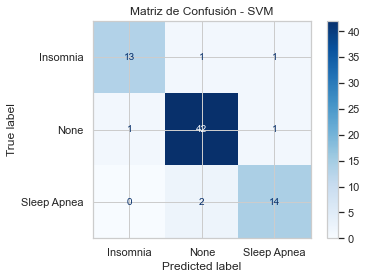

Evaluando modelo: MLP


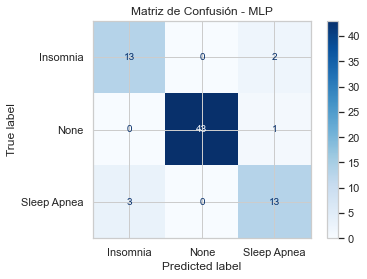

Evaluando modelo: Random Forest


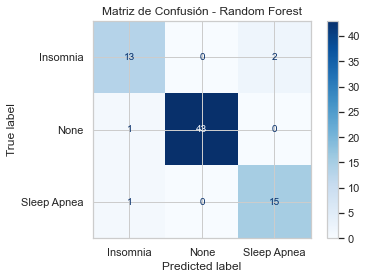

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in trained_models.items():  # Acceder a cada modelo dentro del diccionario
    print(f"Evaluando modelo: {name}")

    # Hacer predicciones
    y_pred = model.predict(X_test)  

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)

    # Mostrar la matriz de confusión
    disp.plot(cmap="Blues")
    plt.title(f'Matriz de Confusión - {name}')
    plt.show()

In [55]:
from sklearn.preprocessing import label_binarize

# Definir las clases de interés en un orden específico
classes = ['Insomnia', 'None', 'Sleep Apnea']

# Binarizar las etiquetas de y_test
y_test_bin = label_binarize(y_test, classes=classes)

# Verificar el resultado de la binarización
print("y_test_bin:\n", y_test_bin[:5])


y_test_bin:
 [[1 0 0]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [1 0 0]]


CURVA ROC-AUC 

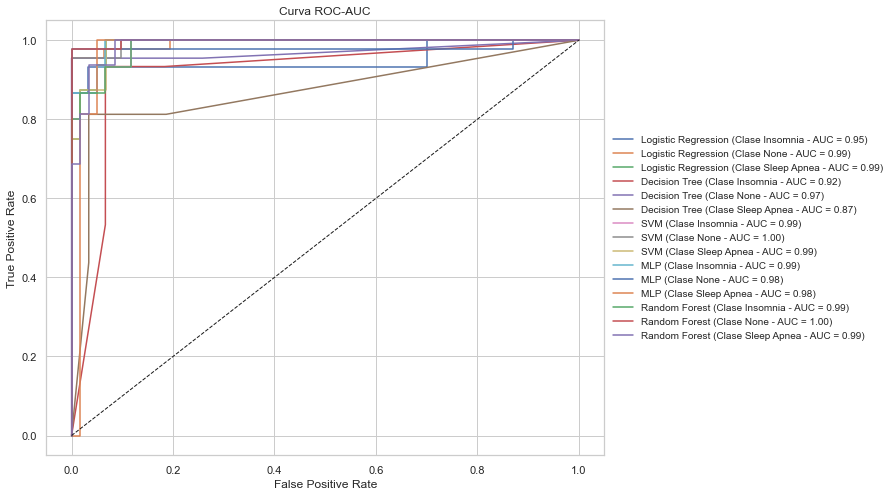

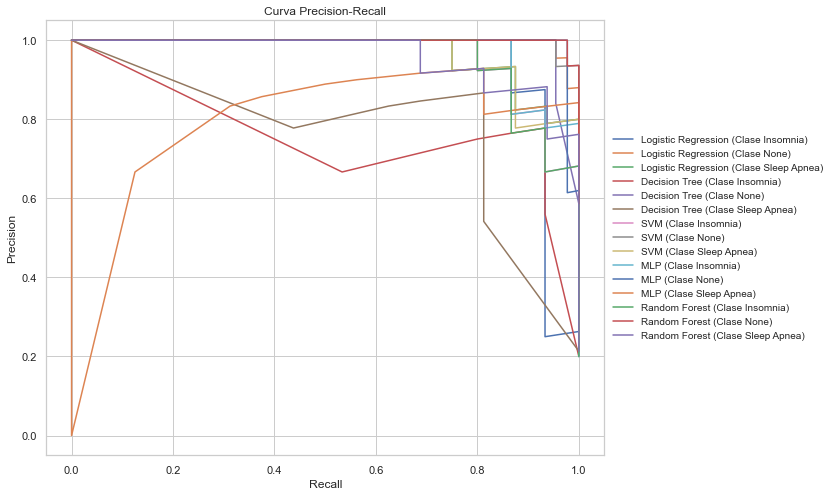

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

# Curva ROC-AUC
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):  # Verificar si el modelo tiene predict_proba
        y_score = model.predict_proba(X_test)  # Probabilidades predichas para cada clase
    else:
        y_score = model.decision_function(X_test)  # Usar las puntuaciones si no tiene predict_proba

    # Calcular la curva ROC y AUC para cada clase
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])  # Cálculo de fpr, tpr
        roc_auc = auc(fpr, tpr)  # Área bajo la curva ROC
        plt.plot(fpr, tpr, label=f"{name} (Clase {classes[i]} - AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)  # Línea diagonal (aleatorio)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC-AUC')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, frameon=False)
plt.show()

# Curva Precision-Recall
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):  # Verificar si el modelo tiene predict_proba
        y_score = model.predict_proba(X_test)  # Probabilidades predichas para cada clase
    else:
        y_score = model.decision_function(X_test)  # Usar las puntuaciones si no tiene predict_proba

    # Calcular Precision-Recall para cada clase
    for i in range(len(classes)):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])  # PR curve
        plt.plot(recall, precision, label=f"{name} (Clase {classes[i]})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, frameon=False)
plt.show()


CURVA PRECISSION RECALL

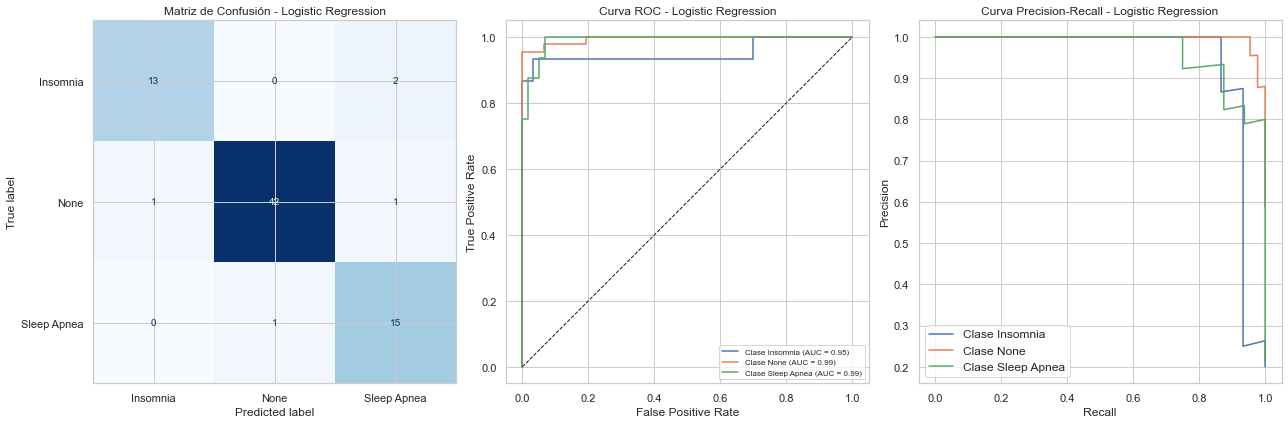

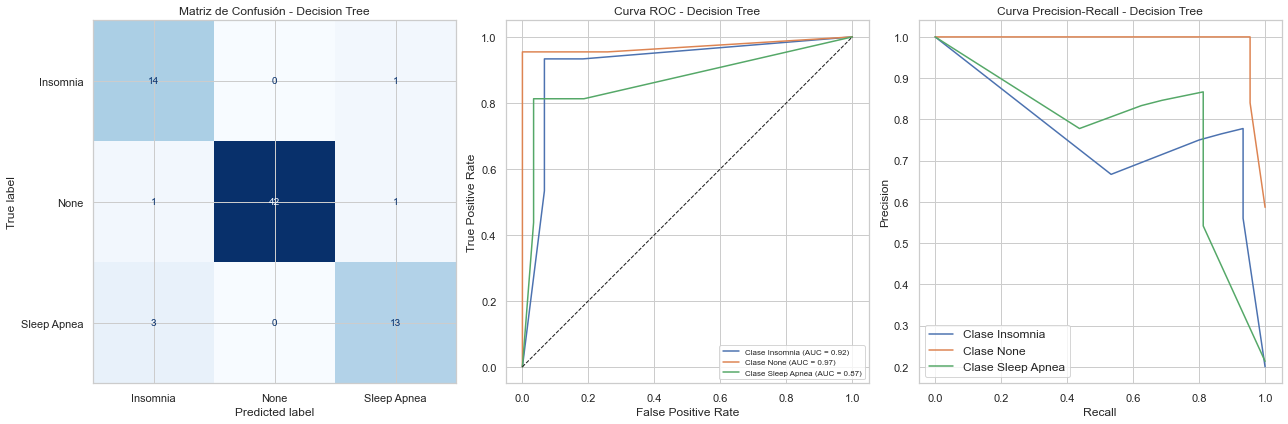

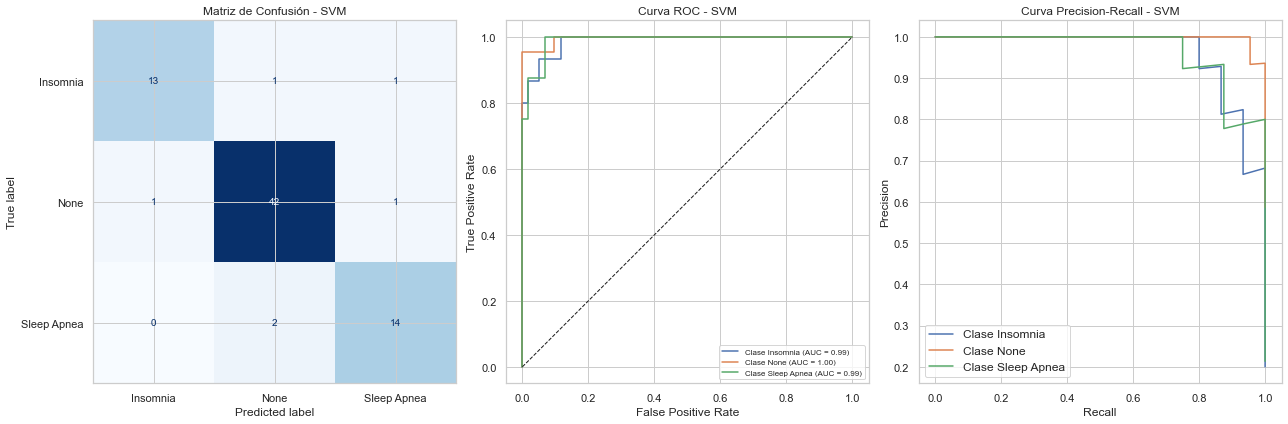

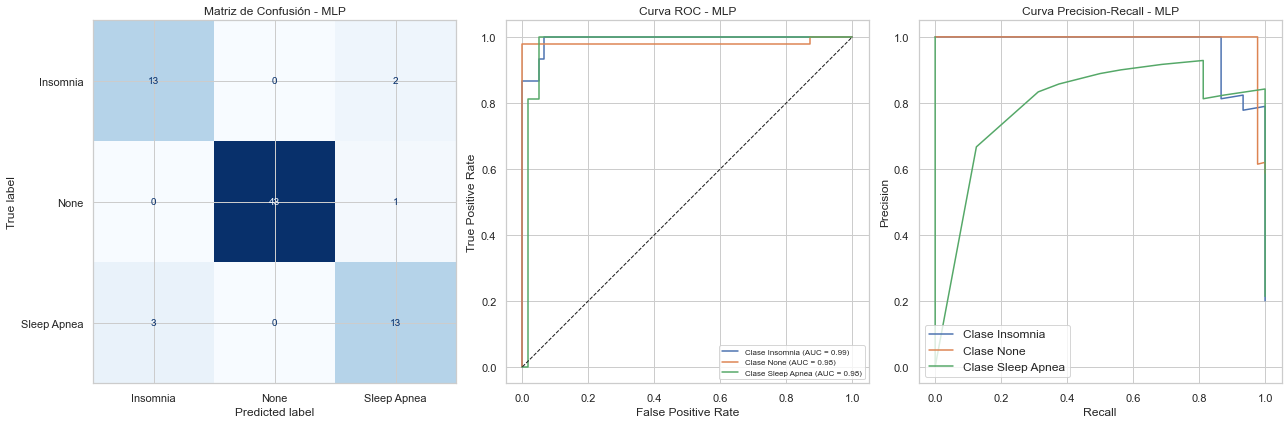

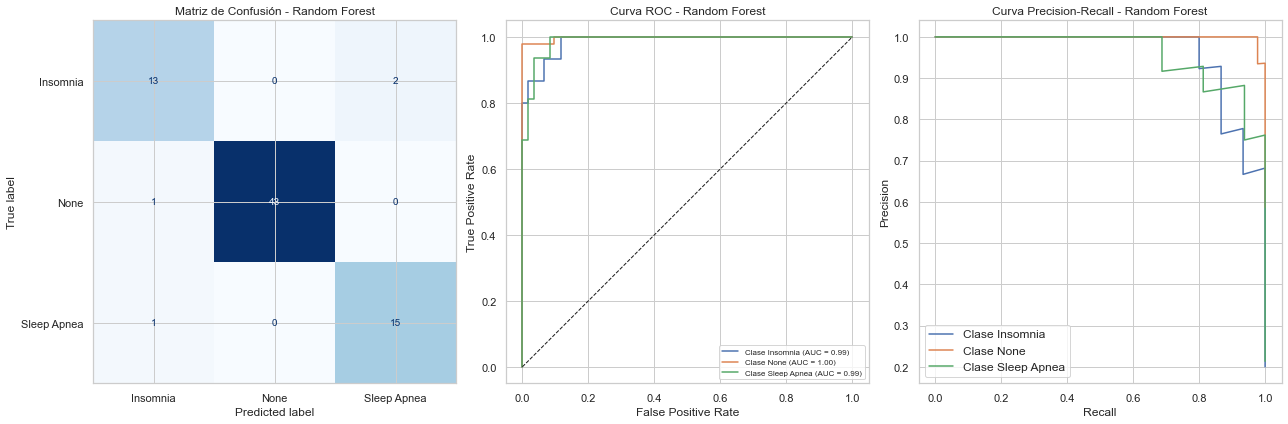

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

# Crear una figura con 3 columnas para cada modelo
for name, model in trained_models.items():
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))  # 1 fila, 3 columnas
    
    # --- 1. Matriz de Confusión ---
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax[0], cmap="Blues", colorbar=False)
    ax[0].set_title(f"Matriz de Confusión - {name}")
    
    # --- 2. Curva ROC (AUC) ---
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
    
    # Calcular la curva ROC y AUC para cada clase
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax[1].plot(fpr, tpr, label=f"Clase {classes[i]} (AUC = {roc_auc:.2f})")
    
    ax[1].plot([0, 1], [0, 1], 'k--', linewidth=1)  # Línea diagonal (aleatorio)
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title(f"Curva ROC - {name}")
    ax[1].legend(loc='lower right', fontsize=8)
    
    # --- 3. Curva Precision-Recall (AUPR) ---
    for i in range(len(classes)):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        ax[2].plot(recall, precision, label=f"Clase {classes[i]}")
    
    ax[2].set_xlabel('Recall')
    ax[2].set_ylabel('Precision')
    ax[2].set_title(f"Curva Precision-Recall - {name}")
    ax[2].legend(loc='lower left', fontsize=12)
    
    # Ajustar el layout para evitar solapamientos
    plt.tight_layout()
    plt.show()


In [58]:
# Modelos con los mejores hiperparámetros
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_split=2, 
                                             min_samples_leaf=2, max_depth=None, 
                                             bootstrap=False, random_state=42),
    "Decision Tree": DecisionTreeClassifier(criterion='gini', max_depth=None, 
                                             min_samples_leaf=4, min_samples_split=10, random_state=42),
    "SVM": SVC(kernel='poly', gamma='scale', C=0.1, random_state=42),
    "MLP": MLPClassifier(solver='adam', learning_rate='constant', hidden_layer_sizes=(50,), 
                          alpha=0.01, activation='tanh', max_iter=1000, random_state=42),
    "Logistic Regression": LogisticRegression(C=10, penalty='l2', solver='liblinear', random_state=42)
}

# Evaluación con validación cruzada
cv_results = {}
for name, model in models.items():
    accuracy = np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy'))
    precision = np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='precision_macro'))
    recall = np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='recall_macro'))
    f1 = np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro'))
    
    cv_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

# Convertir resultados en un DataFrame para visualización
import pandas as pd
cv_results_df = pd.DataFrame(cv_results).T
cv_results_df.sort_values(by="F1-score", ascending=False)


NameError: name 'cross_val_score' is not defined

## GUARDAR EL MODELO 

In [59]:
import joblib

# Guardar el modelo con los mejores hiperparámetros encontrados
joblib.dump(rf_random.best_estimator_, 'random_forest_model.joblib')

print("Modelo guardado exitosamente como 'random_forest_model.joblib'")


Modelo guardado exitosamente como 'random_forest_model.joblib'


PROBAR QUE FUNCIONA

In [60]:
import joblib
from sklearn.metrics import classification_report

# Carga el modelo
model = joblib.load('random_forest_model.joblib')

# Verifica las features esperadas
print("Features del modelo:", model.feature_names_in_)

Features del modelo: ['Age' 'Sleep Duration' 'Quality of Sleep' 'Physical Activity Level'
 'Stress Level' 'BMI Category' 'Heart Rate' 'Daily Steps' 'Gender_Male'
 'Occupation_Doctor' 'Occupation_Engineer' 'Occupation_Lawyer'
 'Occupation_Manager' 'Occupation_Nurse' 'Occupation_Sales Representative'
 'Occupation_Salesperson' 'Occupation_Scientist'
 'Occupation_Software Engineer' 'Occupation_Teacher' 'Systolic BP'
 'Diastolic BP']


In [61]:
import pandas as pd
import numpy as np

# 1. Primero verifica EXACTAMENTE qué columnas espera el modelo
print("Columnas esperadas por el modelo:")
print(model.feature_names_in_)

# 2. Crea un diccionario con TODAS las columnas requeridas
caso_apnea = {
    # Variables numéricas
    'Age': 50,
    'Sleep Duration': 5.5,
    'Quality of Sleep': 3,
    'Physical Activity Level': 20,
    'Stress Level': 8,
    'BMI Category': 3,  # 0=Bajo, 1=Normal, 2=Sobrepeso, 3=Obeso
    'Heart Rate': 90,
    'Daily Steps': 2500,
    
    # Variables one-hot encoded (asegúrate de incluir TODAS las opciones)
    'Gender_Male': 1,
    
    # Ocupaciones (solo marca 1 en la correspondiente)
    'Occupation_Doctor': 0,
    'Occupation_Engineer': 1,
    'Occupation_Lawyer': 0,
    'Occupation_Manager': 0,
    'Occupation_Nurse': 0,
    'Occupation_Sales Representative': 0,
    'Occupation_Salesperson': 0,
    'Occupation_Scientist': 0,
    'Occupation_Software Engineer': 0,
    'Occupation_Teacher': 0,
    
    # Presión arterial
    'Systolic BP': 140,
    'Diastolic BP': 90
}

# 3. Crea el DataFrame asegurando el orden correcto
columnas_requeridas = model.feature_names_in_
df_prueba = pd.DataFrame([caso_apnea])[columnas_requeridas]

# 4. Verifica que no falte ninguna columna
faltantes = set(columnas_requeridas) - set(df_prueba.columns)
if faltantes:
    print("\n❌ Faltan columnas:", faltantes)
else:
    print("\n✅ Todas las columnas presentes")
    
    # 5. Realiza la predicción
    print("\nPredicción:", model.predict(df_prueba))
    print("Probabilidades:", model.predict_proba(df_prueba))

Columnas esperadas por el modelo:
['Age' 'Sleep Duration' 'Quality of Sleep' 'Physical Activity Level'
 'Stress Level' 'BMI Category' 'Heart Rate' 'Daily Steps' 'Gender_Male'
 'Occupation_Doctor' 'Occupation_Engineer' 'Occupation_Lawyer'
 'Occupation_Manager' 'Occupation_Nurse' 'Occupation_Sales Representative'
 'Occupation_Salesperson' 'Occupation_Scientist'
 'Occupation_Software Engineer' 'Occupation_Teacher' 'Systolic BP'
 'Diastolic BP']

✅ Todas las columnas presentes

Predicción: ['Sleep Apnea']
Probabilidades: [[0.24355821 0.13358794 0.62285385]]


In [62]:
# Crea un diccionario base con valores por defecto
datos_base = {col: 0 for col in model.feature_names_in_}

# Actualiza solo las variables importantes
datos_actualizados = {
    'Age': 50,
    'Sleep Duration': 5.5,
    'BMI Category': 3,
    'Gender_Male': 1,
    'Occupation_Engineer': 1  # Cambia según necesites
}

datos_base.update(datos_actualizados)

# Crea DataFrame y predice
df_prueba = pd.DataFrame([datos_base])[model.feature_names_in_]
print("Predicción simplificada:", model.predict_proba(df_prueba))

Predicción simplificada: [[0.13730834 0.75535342 0.10733824]]


In [63]:
def prepare_input(input_data):
    # Inicia con todas las columnas en 0
    default_data = {col: 0 for col in model.feature_names_in_}
    
    # Actualiza con los valores del usuario
    default_data.update({
        'Age': input_data['age'],
        'Sleep Duration': input_data['sleep_duration'],
        # ... completa con todos los campos
        'Occupation_'+input_data['occupation']: 1  # One-hot encoding
    })
    
    return pd.DataFrame([default_data])[model.feature_names_in_]

In [64]:
# Feature importances
importances = pd.DataFrame({
    'Feature': model.feature_names_in_,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Variables más importantes:")
print(importances.head(10))

Variables más importantes:
                    Feature  Importance
5              BMI Category    0.156192
19              Systolic BP    0.140996
20             Diastolic BP    0.138314
1            Sleep Duration    0.106240
0                       Age    0.078989
13         Occupation_Nurse    0.068207
6                Heart Rate    0.063085
3   Physical Activity Level    0.053319
4              Stress Level    0.049471
7               Daily Steps    0.039720


- Optimización de hiperparámetros --> Buscar la mejor configuración de los modelos (GridSearchCV, RandomizedSearchCV)
- Matriz de confusión --> Ver dónde se equivoca el modelo (errores tipo I y tipo III)
- Curva ROC y AUC --> Evaluar el rendimiento general en problemas de clasificación
- Precission-Recall Curve --> Más útil si las clases están desbalanceadas

El modelo predictivo YA hecho lo tenemos que guardar en formato .hst (creo)

Para exportar el modelo, dependiendo de qué tipo sea se exportará en un formato u otro:
- Para modelos de Keras (MLP, si se usa este tipo de red neuronal) --> se exportará en .h5
- Para otros modelos como RandomForest o SVM, se utilizará joblib --> .joblib

Verificación del modelo

In [65]:
import joblib
import pandas as pd
from sklearn.metrics import classification_report

# Carga el modelo
model = joblib.load('random_forest_model.joblib')

# Verifica las características que espera el modelo
print("Características esperadas por el modelo:")
print(model.feature_names_in_)

Características esperadas por el modelo:
['Age' 'Sleep Duration' 'Quality of Sleep' 'Physical Activity Level'
 'Stress Level' 'BMI Category' 'Heart Rate' 'Daily Steps' 'Gender_Male'
 'Occupation_Doctor' 'Occupation_Engineer' 'Occupation_Lawyer'
 'Occupation_Manager' 'Occupation_Nurse' 'Occupation_Sales Representative'
 'Occupation_Salesperson' 'Occupation_Scientist'
 'Occupation_Software Engineer' 'Occupation_Teacher' 'Systolic BP'
 'Diastolic BP']


In [66]:
# Usa tus datos de entrenamiento (X_train) para verificar que las predicciones son consistentes
y_pred = model.predict(X_train)
y_proba = model.predict_proba(X_train)

print("\n🔍 Reporte de clasificación (datos de entrenamiento):")
print(classification_report(y_train, y_pred))

print("\n📊 Probabilidades promedio para cada clase:")
print(pd.DataFrame(y_proba, columns=model.classes_).mean())


🔍 Reporte de clasificación (datos de entrenamiento):
              precision    recall  f1-score   support

    Insomnia       0.90      0.85      0.88        62
        None       0.93      0.95      0.94       175
 Sleep Apnea       0.89      0.89      0.89        62

    accuracy                           0.92       299
   macro avg       0.91      0.90      0.90       299
weighted avg       0.92      0.92      0.92       299


📊 Probabilidades promedio para cada clase:
Insomnia       0.207358
None           0.585284
Sleep Apnea    0.207358
dtype: float64


In [67]:
# Crea casos de prueba manuales
caso_apnea = {
    'Age': 55,  # Edad avanzada
    'Sleep Duration': 4.5,  # Pocas horas de sueño
    'Quality of Sleep': 2,  # Mala calidad
    'Physical Activity Level': 20,  # Baja actividad
    'Stress Level': 9,  # Estrés alto
    'BMI Category': 3,  # Obeso
    'Heart Rate': 95,  # Frecuencia alta
    'Daily Steps': 2000,  # Pocos pasos
    'Gender_Male': 1,  # Hombre
    'Occupation_Engineer': 1,  # Ocupación (solo una en 1)
    # Todas las demás ocupaciones en 0
    'Occupation_Doctor': 0,
    'Occupation_Lawyer': 0,
    # ... completa con todas las occupation_*
    'Systolic BP': 145,  # Presión alta
    'Diastolic BP': 95
}

# Convierte a DataFrame asegurando el orden correcto
df_prueba = pd.DataFrame([caso_apnea])[model.feature_names_in_]

print("\n🧪 Predicción para caso de apnea:")
print("Clase predicha:", model.predict(df_prueba))
print("Probabilidades:", model.predict_proba(df_prueba))

KeyError: "['Occupation_Manager', 'Occupation_Nurse', 'Occupation_Sales Representative', 'Occupation_Salesperson', 'Occupation_Scientist', 'Occupation_Software Engineer', 'Occupation_Teacher'] not in index"

In [68]:
# Toma 3 muestras aleatorias (excluyendo la columna target)
muestras = X_train.sample(3)

print("\n🎯 Predicciones para muestras reales:")
for i, (_, row) in enumerate(muestras.iterrows()):
    print(f"\nMuestra {i+1}:")
    print("Datos:", row.to_dict())
    print("Predicción:", model.predict([row]))
    print("Probabilidades:", model.predict_proba([row]))


🎯 Predicciones para muestras reales:

Muestra 1:
Datos: {'Age': 0.6875, 'Sleep Duration': 0.11111111111111116, 'Quality of Sleep': 0.40000000000000013, 'Physical Activity Level': 1.0, 'Stress Level': 1.0, 'BMI Category': 2.0, 'Heart Rate': 0.4761904761904763, 'Daily Steps': 1.0, 'Gender_Male': 0.0, 'Occupation_Doctor': 0.0, 'Occupation_Engineer': 0.0, 'Occupation_Lawyer': 0.0, 'Occupation_Manager': 0.0, 'Occupation_Nurse': 1.0, 'Occupation_Sales Representative': 0.0, 'Occupation_Salesperson': 0.0, 'Occupation_Scientist': 0.0, 'Occupation_Software Engineer': 0.0, 'Occupation_Teacher': 0.0, 'Systolic BP': 0.9259259259259265, 'Diastolic BP': 1.0}
Predicción: ['Sleep Apnea']
Probabilidades: [[0.00686553 0.02559282 0.96754165]]

Muestra 2:
Datos: {'Age': 0.0625, 'Sleep Duration': 0.0740740740740744, 'Quality of Sleep': 0.40000000000000013, 'Physical Activity Level': 0.0, 'Stress Level': 1.0, 'BMI Category': 1.0, 'Heart Rate': 0.23809523809523814, 'Daily Steps': 0.7142857142857144, 'Gender_

C:\Users\Marina\anaconda3\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Marina\anaconda3\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Marina\anaconda3\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Marina\anaconda3\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Marina\anaconda3\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Marina\anaconda3\lib\site-packages\sklearn\bas

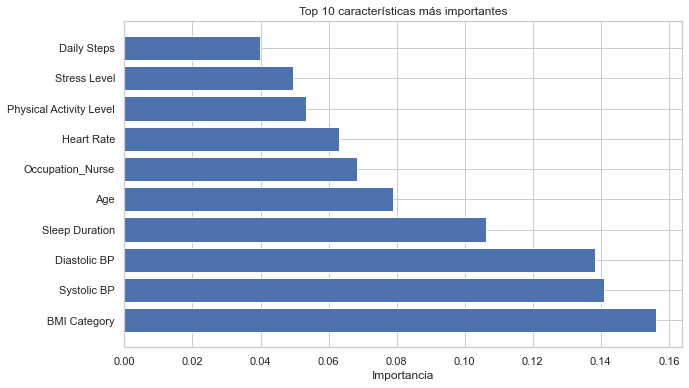

In [69]:
import matplotlib.pyplot as plt

# Obtén importancia de características
importances = pd.DataFrame({
    'Feature': model.feature_names_in_,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][:10], importances['Importance'][:10])
plt.title('Top 10 características más importantes')
plt.xlabel('Importancia')
plt.show()

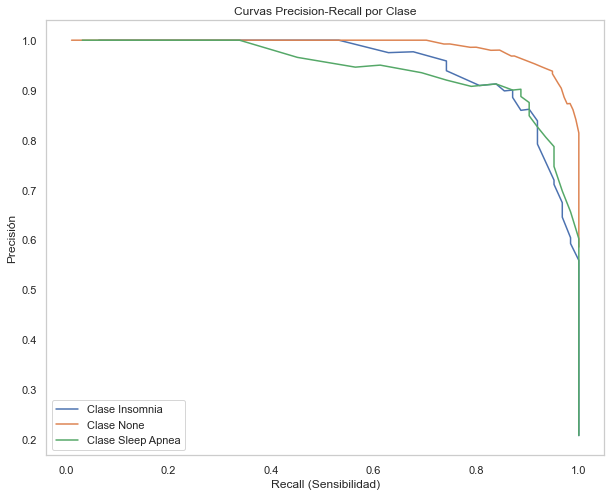

In [70]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Para cada clase, calculamos la curva PR
plt.figure(figsize=(10, 8))

for i, clase in enumerate(model.classes_):
    # Crea etiquetas binarias para esta clase
    y_bin = np.where(y_train == clase, 1, 0)
    y_scores = model.predict_proba(X_train)[:, i]
    
    precision, recall, thresholds = precision_recall_curve(y_bin, y_scores)
    
    # Graficamos omitiendo el último punto (precisión=1, recall=0)
    plt.plot(recall[:-1], precision[:-1], label=f'Clase {clase}')

plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precisión')
plt.title('Curvas Precision-Recall por Clase')
plt.legend()
plt.grid()
plt.show()

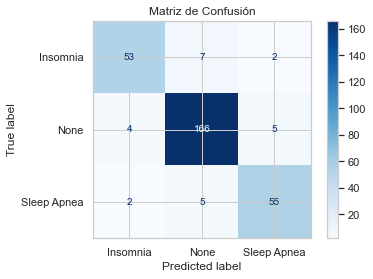

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_train)
cm = confusion_matrix(y_train, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

In [72]:
from sklearn.metrics import classification_report

print("Reporte de Clasificación:")
print(classification_report(y_train, y_pred, target_names=model.classes_))

Reporte de Clasificación:
              precision    recall  f1-score   support

    Insomnia       0.90      0.85      0.88        62
        None       0.93      0.95      0.94       175
 Sleep Apnea       0.89      0.89      0.89        62

    accuracy                           0.92       299
   macro avg       0.91      0.90      0.90       299
weighted avg       0.92      0.92      0.92       299



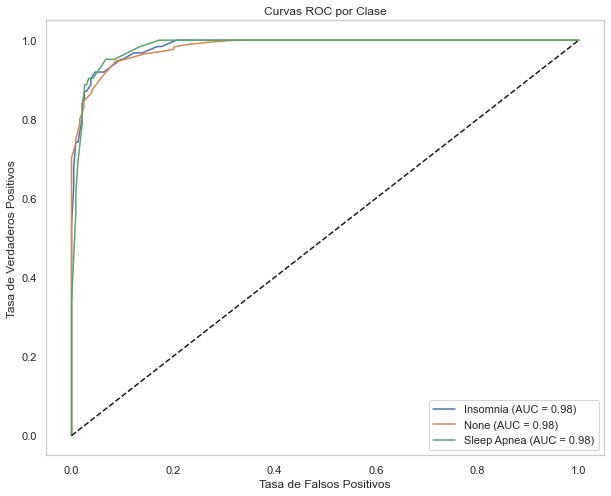

In [73]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar las etiquetas
y_bin = label_binarize(y_train, classes=model.classes_)
n_classes = y_bin.shape[1]

# Calcular curva ROC y área bajo la curva para cada clase
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], model.predict_proba(X_train)[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por Clase')
plt.legend()
plt.grid()
plt.show()

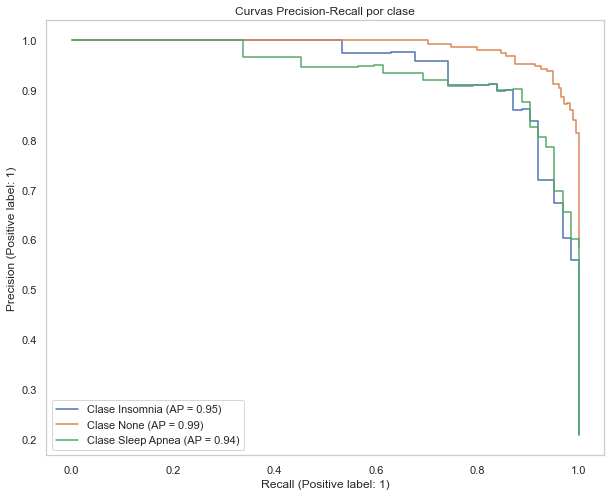

In [74]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(10, 8))
for i, clase in enumerate(model.classes_):
    y_bin = np.where(y_train == clase, 1, 0)
    PrecisionRecallDisplay.from_predictions(
        y_bin, 
        model.predict_proba(X_train)[:, i],
        name=f"Clase {clase}",
        ax=plt.gca()
    )
plt.title('Curvas Precision-Recall por clase')
plt.grid()
plt.show()

In [75]:
import pandas as pd

print(y_train.value_counts(normalize=True))


None           0.585284
Sleep Apnea    0.207358
Insomnia       0.207358
Name: Sleep Disorder, dtype: float64


CALIBRACIÓN DEL MODELO

In [76]:
from sklearn.calibration import CalibratedClassifierCV

# Reentrenar el modelo calibrado (por ejemplo, Random Forest)
calibrated_rf = CalibratedClassifierCV(base_estimator=rf_random.best_estimator_, cv=5)
calibrated_rf.fit(X_train, y_train)

# Guardar este nuevo modelo calibrado
joblib.dump(calibrated_rf, 'modelo_calibrado_random_forest.joblib')


C:\Users\Marina\anaconda3\lib\site-packages\sklearn\calibration.py:300: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


['modelo_calibrado_random_forest.joblib']

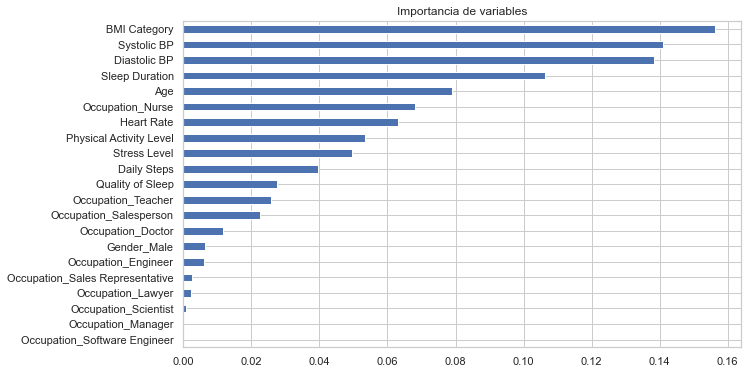

In [77]:
# VISUALIZAR IMPORTANCIA DE CARACTERÍSTICAS
importances = rf_random.best_estimator_.feature_importances_
features = X_train.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(10, 6), title='Importancia de variables')
plt.show()


C:\Users\Marina\anaconda3\lib\site-packages\sklearn\calibration.py:300: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


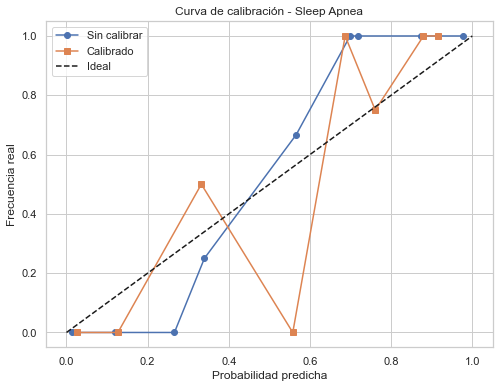

In [78]:
# Calibración de probabilidades para Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt
import joblib

# Entrenar modelo base con mejores hiperparámetros
best_params = {
    'n_estimators': 100,
    'min_samples_split': 2,
    'min_samples_leaf': 2,
    'max_depth': None,
    'bootstrap': False
}
rf = RandomForestClassifier(**best_params, random_state=42)
rf.fit(X_train, y_train)

# Calibrar modelo usando validación cruzada
calibrated_rf = CalibratedClassifierCV(base_estimator=rf, method='isotonic', cv=5)
calibrated_rf.fit(X_train, y_train)

# Guardar modelo calibrado
joblib.dump(calibrated_rf, 'modelo_calibrado_rf.joblib')

# Comparar curva de calibración (usando clase "Sleep Apnea" como ejemplo)
class_index = list(calibrated_rf.classes_).index('Sleep Apnea')

# Modelo sin calibrar
prob_true, prob_pred = calibration_curve((y_test == 'Sleep Apnea'), rf.predict_proba(X_test)[:, class_index], n_bins=10)

# Modelo calibrado
prob_true_cal, prob_pred_cal = calibration_curve((y_test == 'Sleep Apnea'), calibrated_rf.predict_proba(X_test)[:, class_index], n_bins=10)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Sin calibrar')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='Calibrado')
plt.plot([0, 1], [0, 1], 'k--', label='Ideal')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia real')
plt.title('Curva de calibración - Sleep Apnea')
plt.legend()
plt.grid(True)
plt.show()


In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib

# 1. Carga tus datos como lo hacías antes
# X, y = tus datos de entrada y etiquetas

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Entrena con class_weight='balanced'
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)

# 3. Guarda el modelo calibrado
joblib.dump(rf_balanced, "modelo_random_forest_balanceado.pkl")

print("✅ Modelo entrenado y guardado como modelo_random_forest_balanceado.pkl")


✅ Modelo entrenado y guardado como modelo_random_forest_balanceado.pkl


📋 Reporte de clasificación:
               precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.96        75
   macro avg       0.94      0.93      0.94        75
weighted avg       0.96      0.96      0.96        75



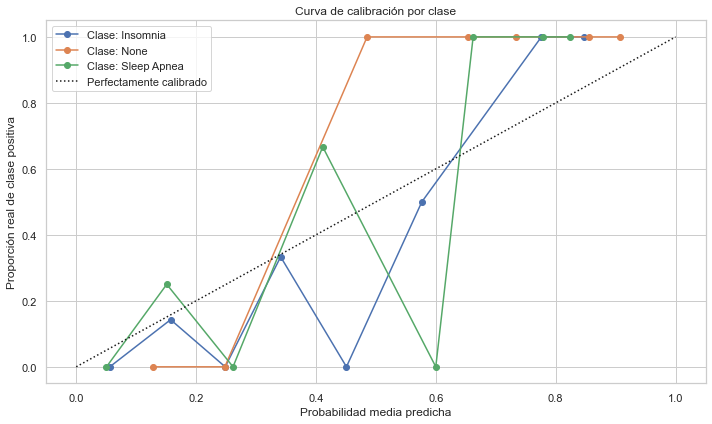

In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib
import numpy as np

# Entrenamiento y calibración de modelo con class_weight='balanced'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Entrenamos el modelo
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)

# Calibramos el modelo con Platt scaling (sigmoid)
calibrated_rf = CalibratedClassifierCV(rf_balanced, method='sigmoid', cv=5)
calibrated_rf.fit(X_train, y_train)

# Guardamos el modelo calibrado
joblib.dump(calibrated_rf, "modelo_random_forest_balanceado_calibrado.pkl")

# Predicciones y evaluación
y_pred = calibrated_rf.predict(X_test)
print("📋 Reporte de clasificación:\n", classification_report(y_test, y_pred))

# Gráfico de curva de calibración para cada clase
plt.figure(figsize=(10, 6))
classes = calibrated_rf.classes_

for i, clase in enumerate(classes):
    prob_pos = calibrated_rf.predict_proba(X_test)[:, i]
    fracc_pos, mean_pred = calibration_curve((y_test == clase).astype(int), prob_pos, n_bins=10)
    plt.plot(mean_pred, fracc_pos, marker='o', label=f"Clase: {clase}")

plt.plot([0, 1], [0, 1], "k:", label="Perfectamente calibrado")
plt.title("Curva de calibración por clase")
plt.xlabel("Probabilidad media predicha")
plt.ylabel("Proporción real de clase positiva")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [81]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


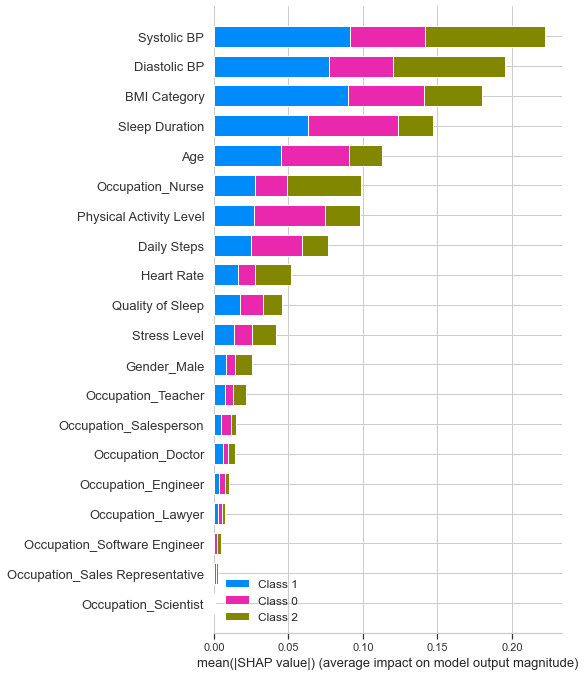

In [82]:
# --- EXPLICABILIDAD CON SHAP ---
import shap
import matplotlib.pyplot as plt

# Crear el explainer para Random Forest
explainer = shap.TreeExplainer(rf_balanced)  # Cambia por tu variable si tiene otro nombre
shap_values = explainer.shap_values(X_test)

# --- Gráfico de importancia global ---
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [82]:
# --- Explicación individual de una predicción ---
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0][0,:], X_test.iloc[0])